In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

import specula
specula.init(0)

from specula import cpuArray

from scipy.interpolate import interp1d

from specula.mmlib.analyse_data import plot_output_data
from specula.mmlib.plot_gain_opt import plot_gain_optimization
from specula.mmlib.utils import reshape_on_mask, get_pupil_mask
from specula.mmlib.compute_iffs import compute_and_save_influence_functions, compute_and_save_dcao_matrix
# from check_calibration import check_calibration

from specula.lib.make_mask import make_mask

2026-05-22 11:42:50,184 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-22 11:42:50,297 [INFO]: [specula]: Default device is GPU number 0
2026-05-22 11:42:50,872 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-22 11:42:50,872 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-22 11:42:50,873 [INFO]: [specula]: Default device is GPU number 0
2026-05-22 11:42:50,873 [INFO]: [specula]: Default device is GPU number 0
2026-05-22 11:42:51,408 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-22 11:42:51,408 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-22 11:42:51,408 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-05-22 11:42:51,410 [INFO]: [specula]: Default device is GPU number 0
2026-05-22 11:42:51,410 [INFO]: [specula]: Default device is GPU number 0
2026-05-22 11:42:51,410 [INFO]: [specula]: Defau

In [2]:
def analyse_tn(tn:str, show:bool=True, step:int=1, return_SNR:bool=False, sn:bool=False):

    phs = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/'+tn+'/atmo_pc_phs.fits')
    slopes = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/'+tn+'/pc_slopes.fits')

    if return_SNR:
        kl = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/ifunc/asm_v30dx_kl_inv.fits')

        mask = np.sum(abs(phs[:,0,:,:])>0,axis=0).astype(bool)
        phases = np.zeros([np.sum(mask),4000])
        for j in range(4000):
            phi = phs[j,1,:,:]
            phi -= np.mean(phi)
            phases[:,j] = phi[mask]
        modes = kl @ phases

        modes_RMS = np.sqrt(np.mean(modes**2,axis=1))
        # tilts = modes[0]

        # amp = 200
        # pp = np.ones(4000)*amp
        # pp[1::2] *= -1
        # tilts -= pp

        # SNR = amp/abs(tilts)

    if show:
        idx = 207
        plt.figure()
        plt.imshow(np.ma.masked_array(phs[idx,1,:,:],mask=~(abs(phs[idx,0,:,:])>0).astype(bool)),origin='lower',cmap='turbo')
        plt.colorbar()
    
    push = slopes[::2]
    pull = slopes[1::2]

    L = int(4000/step)
    screen_corr = np.zeros(L)

    for j in range(L-step):
        A = phs[j,1,:,:].flatten()
        B = phs[j+step,1,:,:].flatten()
        A -= np.mean(A)
        B -= np.mean(B)
        cov = np.dot(A,B.T)
        norm = np.sqrt(np.sum(A**2)) * np.sqrt(np.sum(B**2))
        screen_corr[j] = np.abs(cov/norm)

    dslopes = (push[::step]-pull[::step])/2

    signs = (-1)**np.arange(4000)
    dslopes2 = slopes*signs[:,None]
    # a = (push[:-1]-pull[:-1])/2
    # b = (push[1:]-pull[:-1])/2
    # dslopes2 = np.zeros([2*len(a),slopes.shape[1]])
    # for k in range(len(a)):
    #     dslopes2[2*k,:] = a[k,:]
    #     dslopes2[2*k+1,:] = b[k,:]

    avg_corr = np.mean(screen_corr[1:])

    if show:
        plt.figure()
        plt.plot(screen_corr)
        plt.title(f'Screen correlation: {avg_corr*1e+2:1.0f}%')
        plt.grid()

    if sn:
        tip_slopes = slopes.copy()
    else:
        tip_slopes = dslopes

    N = tip_slopes.shape[0]
    slopes_err = np.zeros(N)

    slopes_avg = tip_slopes[0]
    # slopes_avg = np.mean(tip_slopes,axis=0)

    for j in range(1,N):
        new_slopes_avg = np.mean(tip_slopes[:j],axis=0)
        slopes_err[j] = np.std(new_slopes_avg-slopes_avg)/np.std(slopes_avg)
        slopes_avg = new_slopes_avg.copy()
        
    if sn is False:
        N2 = dslopes2.shape[0]
        slopes2_err = np.zeros(N2)
        slopes2_avg = dslopes2[0]
        for j in range(1,N2):
            new_slopes2_avg = np.mean(dslopes2[:j],axis=0)
            slopes2_err[j] = np.std(new_slopes2_avg-slopes2_avg)/np.std(slopes2_avg)
            slopes2_avg = new_slopes2_avg.copy()

    if show:
        plt.figure()
        plt.loglog(slopes_err[1:],'.')
        if sn is False:
            plt.loglog(slopes2_err[1:],'.')
        plt.grid()
        plt.title('Slope RMS convergence')
        plt.xlabel('# its')
        plt.ylabel(r'$\dfrac{RMS_{new}-RMS_{old}}{RMS_{old}}$')

        plt.figure()
        plt.plot(slopes_avg)
        plt.grid()

    if show and return_SNR:
        total_WFE = np.sqrt(np.sum(modes_RMS**2))
        plt.figure()
        plt.loglog(np.arange(len(modes_RMS))+1,modes_RMS)
        plt.grid()
        plt.xlabel('# KL mode')
        plt.ylabel('amp [nm]')
        plt.title(f'Modes RMS\n{total_WFE:1.0f}nm')

    if return_SNR:
        return slopes_avg,slopes_err,modes_RMS
    else:
        return slopes_avg,slopes_err

In [3]:
# tn = '20260508_145937' # tip only, 30nm amp
# tn = '20260508_150538' # tip only, 30nm amp
# tn = '20260508_160734' # tip only, 30nm amp, screen A
# tn = '20260508_170617' # tip only, 30nm amp, screen B
# tn = '20260508_171644' # tip only, 30nm amp, screen C
# tn = '20260508_172459' # tip only, 30nm amp, screen D

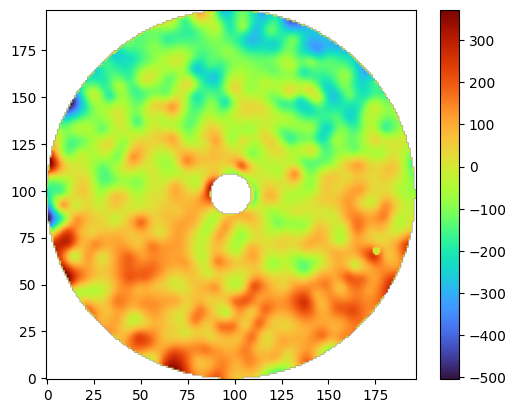

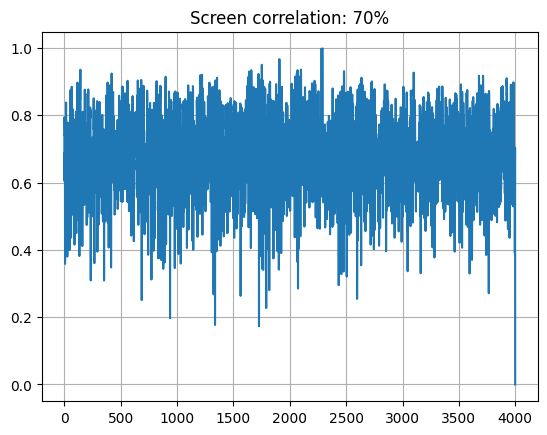

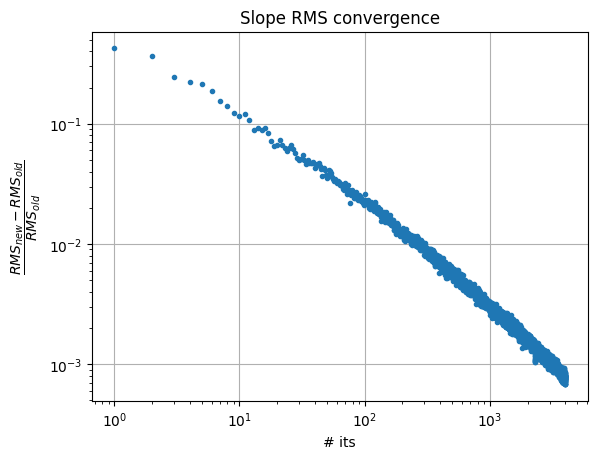

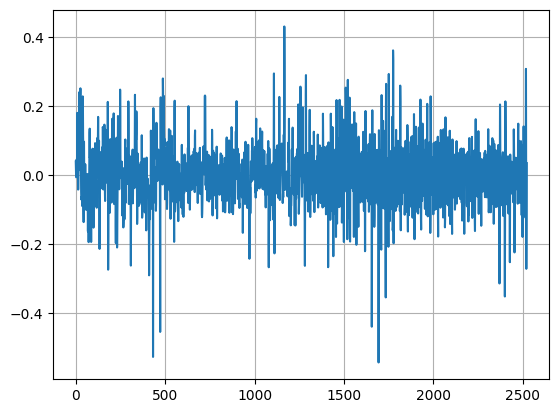

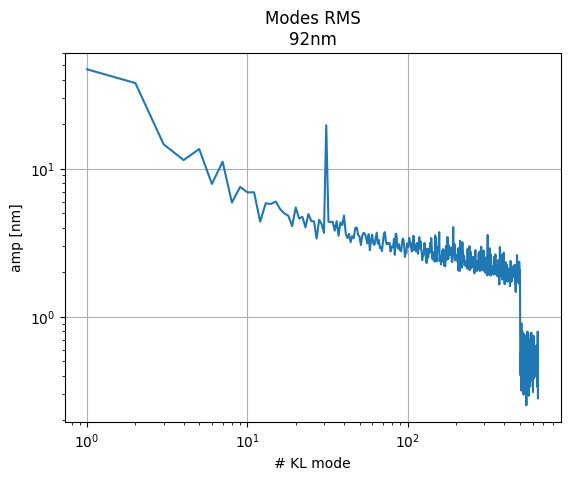

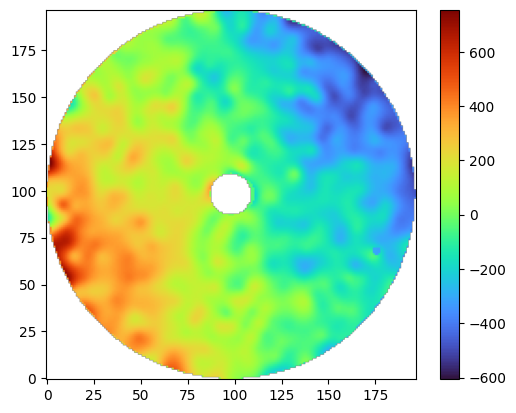

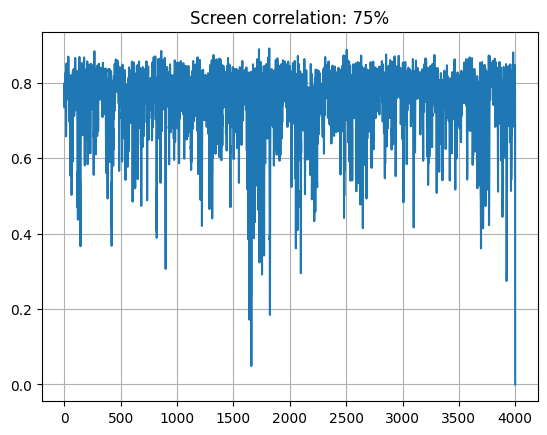

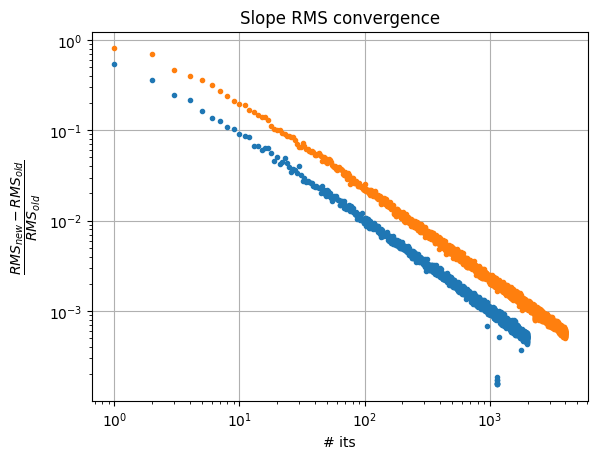

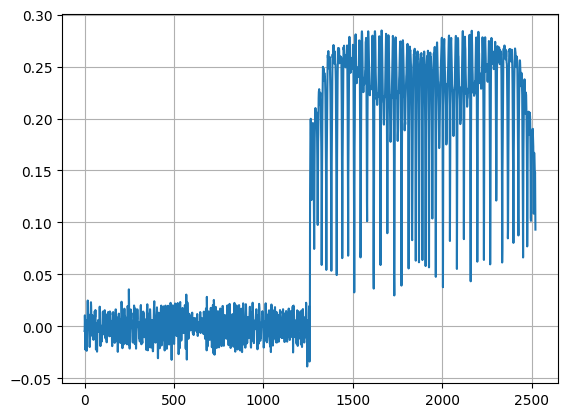

In [4]:
ref_slopes,_ = analyse_tn(tn='20260508_150538',show=False)
pc_slopes,pc_rms,modes_rms = analyse_tn(tn='20260511_092150',return_SNR=True,sn=True)
# pc_slopes_B,pc_rms_B = analyse_tn(tn='20260508_160734')
# pc_slopes_C,pc_rms_C = analyse_tn(tn='20260508_171644')
# pc_slopes_D,pc_rms_D = analyse_tn(tn='20260508_172459')
pc_slopes,pc_rms = analyse_tn(tn='20260511_083817',show=False)
pc_slopes_B,pc_rms_B = analyse_tn(tn='20260511_084128')
# pc_slopes_B,pc_rms_B = analyse_tn(tn='20260511_093305')

In [64]:
tn = '20260511_084128'
phs = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/'+tn+'/atmo_pc_phs.fits')
syn_seeing_tail = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/20260522_142805/atmo_screens.fits')[:4000,:,:,:]

frankenscreen = phs + syn_seeing_tail

kl = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/ifunc/asm_v30dx_kl_inv.fits')
mask = np.sum(abs(phs[:,0,:,:])>0,axis=0).astype(bool)

def get_modes_rms(phs,mask):
    phases = np.zeros([np.sum(mask),4000])
    for j in range(4000):
        phi = phs[j,1,:,:]
        phi -= np.mean(phi)
        phases[:,j] = phi[mask]
    modes = kl @ phases
    modes_RMS = np.sqrt(np.mean(modes**2,axis=1))
    return modes_RMS

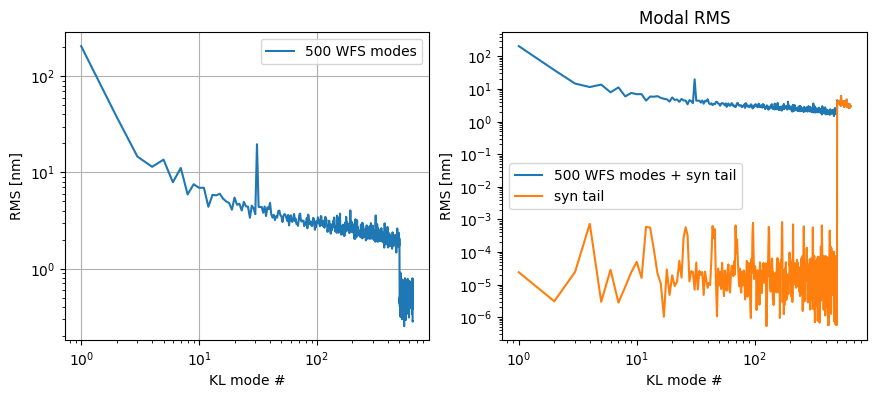

In [71]:
phs_rms = get_modes_rms(phs,mask)
syn_rms = get_modes_rms(syn_seeing_tail,mask)
frankie_rms = get_modes_rms(frankenscreen,mask)

x = np.arange(len(phs_rms))+1

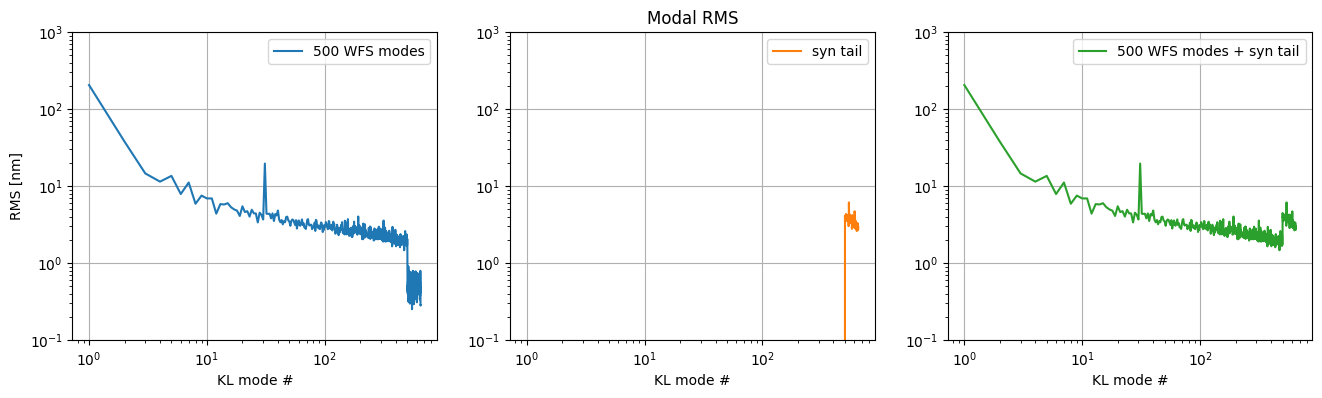

In [74]:
plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.loglog(x,phs_rms,label='500 WFS modes',c='C0')
plt.xlabel('KL mode #')
plt.ylabel('RMS [nm]')
plt.ylim([1e-1,1e+3])
plt.legend()
plt.grid()
plt.subplot(1,3,2)
plt.loglog(x,syn_rms,label='syn tail',c='C1')
plt.title('Modal RMS')
plt.xlabel('KL mode #')
plt.ylim([1e-1,1e+3])
plt.legend()
plt.grid()
plt.subplot(1,3,3)
plt.loglog(x,frankie_rms,label='500 WFS modes + syn tail',c='C2')
plt.xlabel('KL mode #')
plt.ylim([1e-1,1e+3])
plt.legend()
plt.grid()

Text(0.5, 1.0, 'Franken-screen\n')

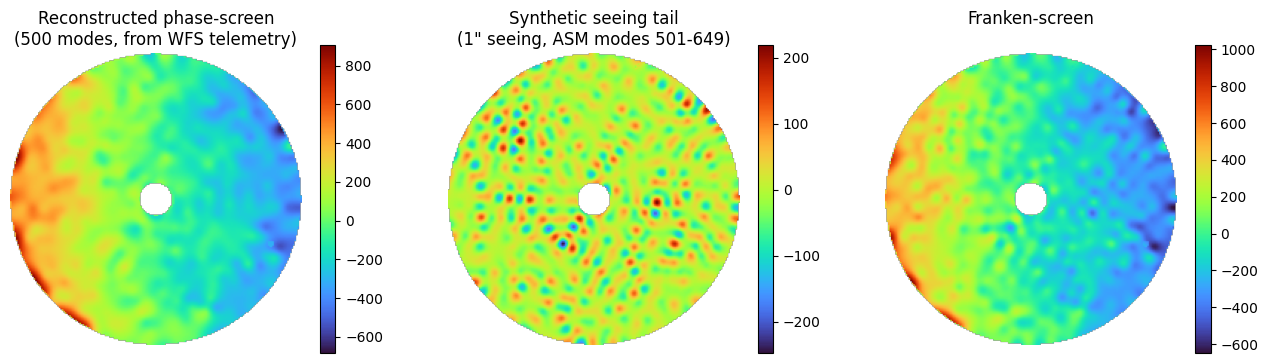

In [75]:
idx = 307
plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.imshow(np.ma.masked_array(phs[idx,1,:,:],mask=~(mask.astype(bool))),origin='lower',cmap='turbo')
plt.title('Reconstructed phase-screen\n(500 modes, from WFS telemetry)')
plt.colorbar()
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(np.ma.masked_array(syn_seeing_tail[idx,1,:,:],mask=~(mask.astype(bool))),origin='lower',cmap='turbo')
plt.colorbar()
plt.axis('off')
plt.title('Synthetic seeing tail\n(1" seeing, ASM modes 501-649)')
plt.subplot(1,3,3)
plt.imshow(np.ma.masked_array(frankenscreen[idx,1,:,:],mask=~(mask.astype(bool))),origin='lower',cmap='turbo')
plt.colorbar()
plt.axis('off')
plt.title('Franken-screen\n')

In [5]:
# plt.figure()
# plt.loglog(pc_rms,'.',label='no shuffle')
# plt.loglog(pc_rms_shuffle,'.',label='shuffle')
# plt.legend()
# plt.grid()
# plt.ylim([2e-3,1])

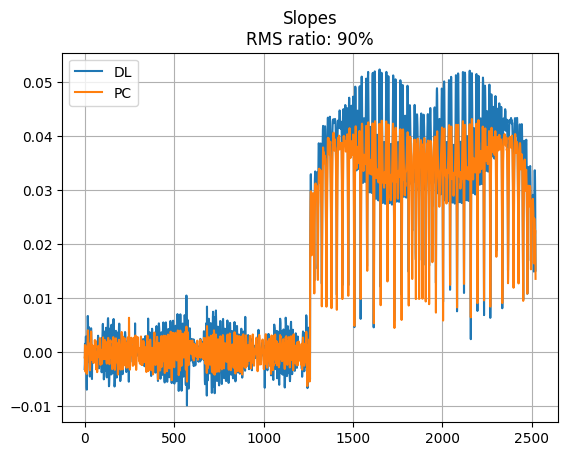

In [6]:
avg_pc_slopes = (pc_slopes*2+pc_slopes_B)/2*30/200

rms_ratio =  np.std(avg_pc_slopes)/np.std(ref_slopes)

plt.figure()
# plt.plot(pc_slopes_shuffle)
plt.plot(ref_slopes,label='DL')
plt.plot(avg_pc_slopes,label='PC')
plt.legend()
plt.title(f'Slopes\nRMS ratio: {rms_ratio*1e+2:1.0f}%')
plt.grid()


In [ ]:
syn_seeing_tail = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/20260522_140934/atmo_screens.fits')[:4000,1,:,:]

In [7]:
# pyr_mask = get_pupil_mask(npix=120,filepath='/raid1/mmenessini/calibration/SOUL/KLv30dx/pupils/pyr_pupdata_40x40.fits')

# plt.figure()
# plt.imshow(pyr_mask)

In [8]:
# soul_dir = '/raid1/mmenessini/results/SOUL/KLv30dx'
# calib_dir = '/raid1/mmenessini/calibration/SOUL/KLv30dx'
# plot_output_data(root_dir=soul_dir,calib_dir=calib_dir,tn='20260506_092825')

In [9]:
im3_pc06 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s0.6_c20260506_092825_im.fits')
im3_pc08 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s0.8_c20260506_092825_im.fits')
im3_pc10 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.0_c20260506_092825_im.fits')
im3_pc12 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.2_c20260506_092825_im.fits')
im3_pc14 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.4_c20260506_092825_im.fits')

im_pyr3_pc500 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.0_c20260506_092825_zerofit_im.fits')
im_pyr1_pc500 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr1.0_s1.0_c20260506_092825_zerofit_im.fits')
im_pyr0_pc500 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr0.0_s1.0_c20260506_092825_zerofit_im.fits')

im_pyr3_pc648 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.0_c20260506_092825_nofit_im.fits')
im_pyr1_pc648 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr1.0_s1.0_c20260506_092825_nofit_im.fits')
im_pyr0_pc648 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr0.0_s1.0_c20260506_092825_nofit_im.fits')

im_pyr3_pcinf = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_s1.0_c20260506_092825_im.fits')
im_pyr1_pcinf = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr1.0_s1.0_c20260506_092825_im.fits')
im_pyr0_pcinf = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr0.0_s1.0_c20260506_092825_im.fits')

In [10]:
im = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_40x40_im.fits')
im1 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr1.0_40x40_im.fits')
im0 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr0.0_40x40_im.fits')
N = 500
im = im[:,:N]
norm_diag = lambda im: np.diag(im.T @ im)

# norm06 = norm_diag(im_pc06)
# norm08 = norm_diag(im_pc08)
# norm10 = norm_diag(im_pc10)
# norm12 = norm_diag(im_pc12)
# norm14 = norm_diag(im_pc14)

In [11]:
rec = cpuArray(specula.xp.linalg.pinv(specula.xp.array(im)))
rec3_pc648 = cpuArray(specula.xp.linalg.pinv(specula.xp.array(im_pyr3_pc648)))
rec3_pc500 = cpuArray(specula.xp.linalg.pinv(specula.xp.array(im_pyr3_pc500)))
rec3_pcinf = cpuArray(specula.xp.linalg.pinv(specula.xp.array(im_pyr3_pcinf)))

In [12]:
rec1 = cpuArray(specula.xp.linalg.pinv(specula.xp.array(im1)))
rec0 = cpuArray(specula.xp.linalg.pinv(specula.xp.array(im0)))

In [13]:
rec0_pc648 = cpuArray(specula.xp.linalg.pinv(specula.xp.array(im_pyr0_pc648)))
rec0_pc500 = cpuArray(specula.xp.linalg.pinv(specula.xp.array(im_pyr0_pc500)))
rec0_pcinf = cpuArray(specula.xp.linalg.pinv(specula.xp.array(im_pyr0_pcinf)))

In [14]:
rec1_pc648 = cpuArray(specula.xp.linalg.pinv(specula.xp.array(im_pyr1_pc648)))
rec1_pc500 = cpuArray(specula.xp.linalg.pinv(specula.xp.array(im_pyr1_pc500)))
rec1_pcinf = cpuArray(specula.xp.linalg.pinv(specula.xp.array(im_pyr1_pcinf)))

In [15]:
im0_pc06 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr0.0_s0.6_c20260506_092825_im.fits')
im0_pc08 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr0.0_s0.8_c20260506_092825_im.fits')
im0_pc10 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr0.0_s1.0_c20260506_092825_im.fits')
im0_pc12 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr0.0_s1.2_c20260506_092825_im.fits')
im0_pc14 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr0.0_s1.4_c20260506_092825_im.fits')

In [16]:
im1_pc06 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr1.0_s0.6_c20260506_092825_im.fits')
im1_pc08 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr1.0_s0.8_c20260506_092825_im.fits')
im1_pc10 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr1.0_s1.0_c20260506_092825_im.fits')
im1_pc12 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr1.0_s1.2_c20260506_092825_im.fits')
im1_pc14 = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr1.0_s1.4_c20260506_092825_im.fits')

In [17]:
og_p3_dl_s10 = np.diag(rec @ im3_pc10) #np.diag(im.T @ im_pc10)/norm10
og_p3_pc500_s10 = np.diag(rec3_pc500 @ im3_pc10) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p3_pc648_s10 = np.diag(rec3_pc648 @ im3_pc10) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p3_pcinf_s10 = np.diag(rec3_pcinf @ im3_pc10) # np.diag(im_pyr3_pcinf.T @ im_pc10)/norm10

og_p3_dl_s06 = np.diag(rec @ im3_pc06) #np.diag(im.T @ im_pc10)/norm10
og_p3_pc500_s06 = np.diag(rec3_pc500 @ im3_pc06) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p3_pc648_s06 = np.diag(rec3_pc648 @ im3_pc06) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p3_pcinf_s06 = np.diag(rec3_pcinf @ im3_pc06) # np.diag(im_pyr3_pcinf.T @ im_pc10)/norm10

og_p3_dl_s08 = np.diag(rec @ im3_pc08) #np.diag(im.T @ im_pc10)/norm10
og_p3_pc500_s08 = np.diag(rec3_pc500 @ im3_pc08) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p3_pc648_s08 = np.diag(rec3_pc648 @ im3_pc08) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p3_pcinf_s08 = np.diag(rec3_pcinf @ im3_pc08) # np.diag(im_pyr3_pcinf.T @ im_pc10)/norm10

og_p3_dl_s12 = np.diag(rec @ im3_pc12) #np.diag(im.T @ im_pc10)/norm10
og_p3_pc500_s12 = np.diag(rec3_pc500 @ im3_pc12) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p3_pc648_s12 = np.diag(rec3_pc648 @ im3_pc12) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p3_pcinf_s12 = np.diag(rec3_pcinf @ im3_pc12) # np.diag(im_pyr3_pcinf.T @ im_pc10)/norm10

og_p3_dl_s14 = np.diag(rec @ im3_pc14) #np.diag(im.T @ im_pc10)/norm10
og_p3_pc500_s14 = np.diag(rec3_pc500 @ im3_pc14) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p3_pc648_s14 = np.diag(rec3_pc648 @ im3_pc14) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p3_pcinf_s14 = np.diag(rec3_pcinf @ im3_pc14) # np.diag(im_pyr3_pcinf.T @ im_pc10)/norm10

x = np.arange(N)+1
ogc_idx = 30


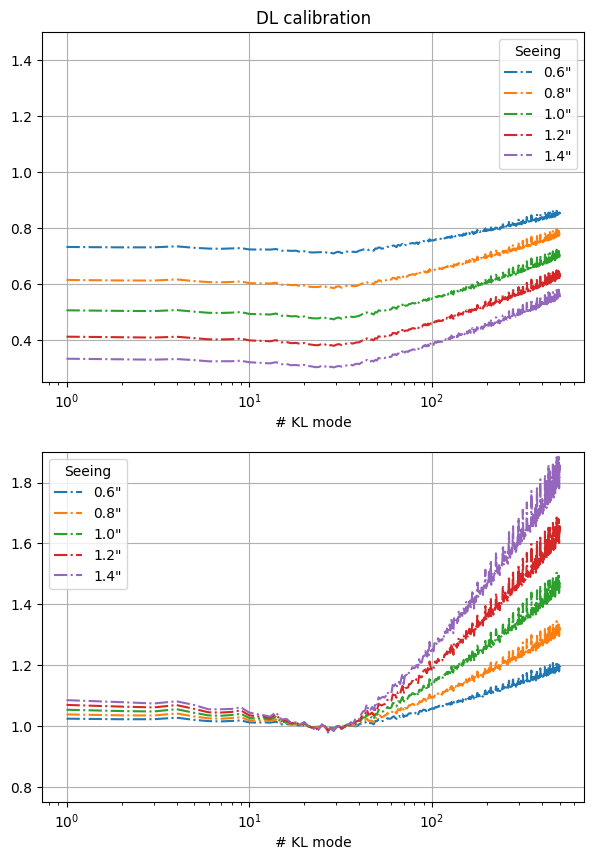

In [18]:
plt.figure(figsize=(7,10))
plt.subplot(2,1,1)
plt.semilogx(x,og_p3_dl_s06,'-.',label='0.6"')
plt.semilogx(x,og_p3_dl_s08,'-.',label='0.8"')
plt.semilogx(x,og_p3_dl_s10,'-.',label='1.0"')
plt.semilogx(x,og_p3_dl_s12,'-.',label='1.2"')
plt.semilogx(x,og_p3_dl_s14,'-.',label='1.4"')
plt.ylim([0.25,1.5])
plt.title('DL calibration')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()
plt.subplot(2,1,2)
plt.semilogx(x,og_p3_dl_s06/og_p3_dl_s06[ogc_idx],'-.',label='0.6"')
plt.semilogx(x,og_p3_dl_s08/og_p3_dl_s08[ogc_idx],'-.',label='0.8"')
plt.semilogx(x,og_p3_dl_s10/og_p3_dl_s10[ogc_idx],'-.',label='1.0"')
plt.semilogx(x,og_p3_dl_s12/og_p3_dl_s12[ogc_idx],'-.',label='1.2"')
plt.semilogx(x,og_p3_dl_s14/og_p3_dl_s14[ogc_idx],'-.',label='1.4"')
plt.ylim([0.75,1.9])
# plt.title('Optical gain after OGC\nDL calibration')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()

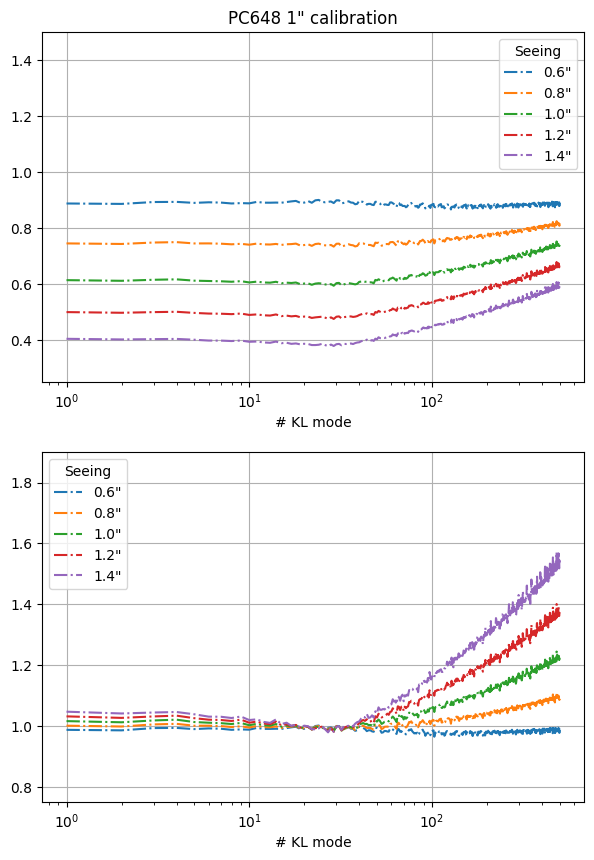

In [19]:
plt.figure(figsize=(7,10))
plt.subplot(2,1,1)
plt.semilogx(x,og_p3_pc648_s06,'-.',label='0.6"')
plt.semilogx(x,og_p3_pc648_s08,'-.',label='0.8"')
plt.semilogx(x,og_p3_pc648_s10,'-.',label='1.0"')
plt.semilogx(x,og_p3_pc648_s12,'-.',label='1.2"')
plt.semilogx(x,og_p3_pc648_s14,'-.',label='1.4"')
plt.ylim([0.25,1.5])
plt.title('PC648 1" calibration')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()
plt.subplot(2,1,2)
plt.semilogx(x,og_p3_pc648_s06/og_p3_pc648_s06[ogc_idx],'-.',label='0.6"')
plt.semilogx(x,og_p3_pc648_s08/og_p3_pc648_s08[ogc_idx],'-.',label='0.8"')
plt.semilogx(x,og_p3_pc648_s10/og_p3_pc648_s10[ogc_idx],'-.',label='1.0"')
plt.semilogx(x,og_p3_pc648_s12/og_p3_pc648_s12[ogc_idx],'-.',label='1.2"')
plt.semilogx(x,og_p3_pc648_s14/og_p3_pc648_s14[ogc_idx],'-.',label='1.4"')
plt.ylim([0.75,1.9])
# plt.title('Optical gain after OGC\nPC648 calibration 1"')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()

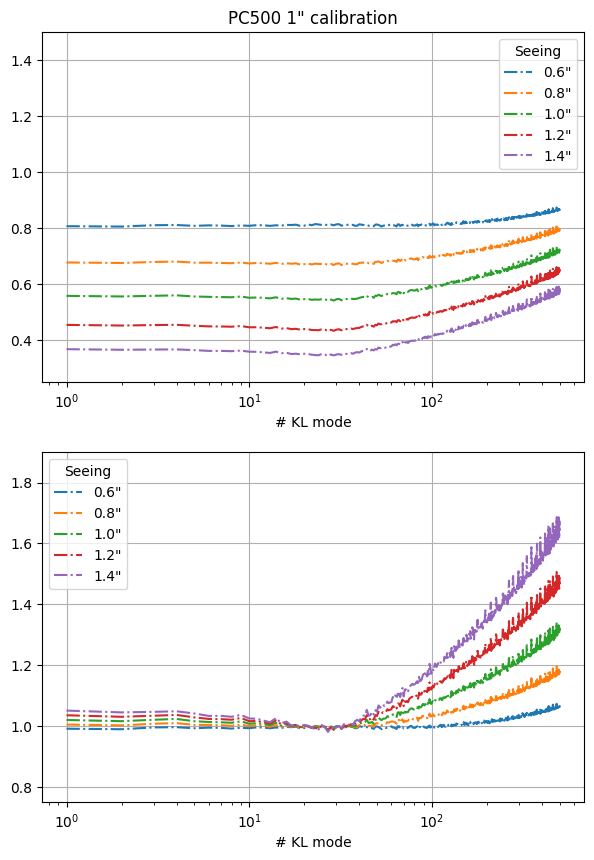

In [20]:
plt.figure(figsize=(7,10))
plt.subplot(2,1,1)
plt.semilogx(x,og_p3_pc500_s06,'-.',label='0.6"')
plt.semilogx(x,og_p3_pc500_s08,'-.',label='0.8"')
plt.semilogx(x,og_p3_pc500_s10,'-.',label='1.0"')
plt.semilogx(x,og_p3_pc500_s12,'-.',label='1.2"')
plt.semilogx(x,og_p3_pc500_s14,'-.',label='1.4"')
plt.ylim([0.25,1.5])
plt.title('PC500 1" calibration')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()
plt.subplot(2,1,2)
plt.semilogx(x,og_p3_pc500_s06/og_p3_pc500_s06[ogc_idx],'-.',label='0.6"')
plt.semilogx(x,og_p3_pc500_s08/og_p3_pc500_s08[ogc_idx],'-.',label='0.8"')
plt.semilogx(x,og_p3_pc500_s10/og_p3_pc500_s10[ogc_idx],'-.',label='1.0"')
plt.semilogx(x,og_p3_pc500_s12/og_p3_pc500_s12[ogc_idx],'-.',label='1.2"')
plt.semilogx(x,og_p3_pc500_s14/og_p3_pc500_s14[ogc_idx],'-.',label='1.4"')
plt.ylim([0.75,1.9])
# plt.title('Optical gain after OGC\nPC648 calibration 1"')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()

<>:9: SyntaxWarning: invalid escape sequence '\i'
<>:9: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_3732045/1599578020.py:9: SyntaxWarning: invalid escape sequence '\i'
  plt.title('PC$\infty$ 1" calibration')


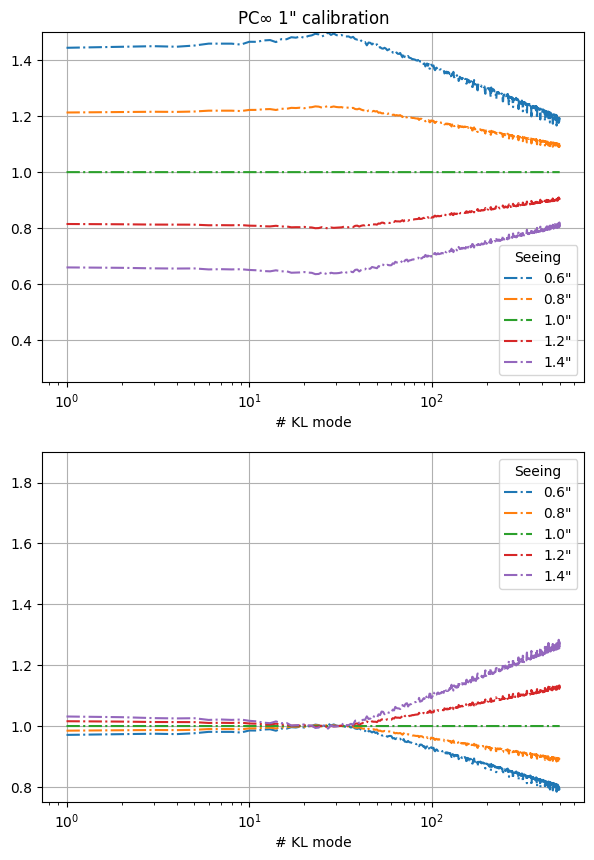

In [21]:
plt.figure(figsize=(7,10))
plt.subplot(2,1,1)
plt.semilogx(x,og_p3_pcinf_s06,'-.',label='0.6"')
plt.semilogx(x,og_p3_pcinf_s08,'-.',label='0.8"')
plt.semilogx(x,og_p3_pcinf_s10,'-.',label='1.0"')
plt.semilogx(x,og_p3_pcinf_s12,'-.',label='1.2"')
plt.semilogx(x,og_p3_pcinf_s14,'-.',label='1.4"')
plt.ylim([0.25,1.5])
plt.title('PC$\infty$ 1" calibration')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()
plt.subplot(2,1,2)
plt.semilogx(x,og_p3_pcinf_s06/og_p3_pcinf_s06[ogc_idx],'-.',label='0.6"')
plt.semilogx(x,og_p3_pcinf_s08/og_p3_pcinf_s08[ogc_idx],'-.',label='0.8"')
plt.semilogx(x,og_p3_pcinf_s10/og_p3_pcinf_s10[ogc_idx],'-.',label='1.0"')
plt.semilogx(x,og_p3_pcinf_s12/og_p3_pcinf_s12[ogc_idx],'-.',label='1.2"')
plt.semilogx(x,og_p3_pcinf_s14/og_p3_pcinf_s14[ogc_idx],'-.',label='1.4"')
plt.ylim([0.75,1.9])
# plt.title('Optical gain after OGC\nPCinf calibration 1"')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()

In [22]:
og_p1_dl_s10 = np.diag(rec1 @ im1_pc10) #np.diag(im.T @ im_pc10)/norm10
og_p1_pc500_s10 = np.diag(rec1_pc500 @ im1_pc10) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p1_pc648_s10 = np.diag(rec1_pc648 @ im1_pc10) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p1_pcinf_s10 = np.diag(rec1_pcinf @ im1_pc10) # np.diag(im_pyr3_pcinf.T @ im_pc10)/norm10

og_p1_dl_s06 = np.diag(rec1 @ im1_pc06) #np.diag(im.T @ im_pc10)/norm10
og_p1_pc500_s06 = np.diag(rec1_pc500 @ im1_pc06) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p1_pc648_s06 = np.diag(rec1_pc648 @ im1_pc06) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p1_pcinf_s06 = np.diag(rec1_pcinf @ im1_pc06) # np.diag(im_pyr3_pcinf.T @ im_pc10)/norm10

og_p1_dl_s08 = np.diag(rec1 @ im1_pc08) #np.diag(im.T @ im_pc10)/norm10
og_p1_pc500_s08 = np.diag(rec1_pc500 @ im1_pc08) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p1_pc648_s08 = np.diag(rec1_pc648 @ im1_pc08) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p1_pcinf_s08 = np.diag(rec1_pcinf @ im1_pc08) # np.diag(im_pyr3_pcinf.T @ im Pc10)/norm10

og_p1_dl_s12 = np.diag(rec1 @ im1_pc12) #np.diag(im.T @ im_pc10)/norm10
og_p1_pc500_s12 = np.diag(rec1_pc500 @ im1_pc12) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p1_pc648_s12 = np.diag(rec1_pc648 @ im1_pc12) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p1_pcinf_s12 = np.diag(rec1_pcinf @ im1_pc12) # np.diag(im_pyr3_pcinf.T @ im_pc10)/norm10

og_p1_dl_s14 = np.diag(rec1 @ im1_pc14) #np.diag(im.T @ im_pc10)/norm10
og_p1_pc500_s14 = np.diag(rec1_pc500 @ im1_pc14) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p1_pc648_s14 = np.diag(rec1_pc648 @ im1_pc14) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p1_pcinf_s14 = np.diag(rec1_pcinf @ im1_pc14) # np.diag(im_pyr3_pcinf.T @ im_pc10)/norm10

In [23]:
og_p0_dl_s10 = np.diag(rec0 @ im0_pc10) #np.diag(im.T @ im_pc10)/norm10
og_p0_pc500_s10 = np.diag(rec0_pc500 @ im0_pc10) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p0_pc648_s10 = np.diag(rec0_pc648 @ im0_pc10) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p0_pcinf_s10 = np.diag(rec0_pcinf @ im0_pc10) # np.diag(im_pyr3_pcinf.T @ im_pc10)/norm10

og_p0_dl_s06 = np.diag(rec0 @ im0_pc06) #np.diag(im.T @ im_pc10)/norm10
og_p0_pc500_s06 = np.diag(rec0_pc500 @ im0_pc06) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p0_pc648_s06 = np.diag(rec0_pc648 @ im0_pc06) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p0_pcinf_s06 = np.diag(rec0_pcinf @ im0_pc06) # np.diag(im_pyr3_pcinf.T @ im_pc10)/norm10

og_p0_dl_s08 = np.diag(rec0 @ im0_pc08) #np.diag(im.T @ im_pc10)/norm10
og_p0_pc500_s08 = np.diag(rec0_pc500 @ im0_pc08) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p0_pc648_s08 = np.diag(rec0_pc648 @ im0_pc08) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p0_pcinf_s08 = np.diag(rec0_pcinf @ im0_pc08) # np.diag(im_pyr3_pcinf.T @ im_pc10)/norm10

og_p0_dl_s12 = np.diag(rec0 @ im0_pc12) #np.diag(im.T @ im_pc10)/norm10
og_p0_pc500_s12 = np.diag(rec0_pc500 @ im0_pc12) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p0_pc648_s12 = np.diag(rec0_pc648 @ im0_pc12) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p0_pcinf_s12 = np.diag(rec0_pcinf @ im0_pc12) # np.diag(im_pyr3_pcinf.T @ im_pc10)/norm10

og_p0_dl_s14 = np.diag(rec0 @ im0_pc14) #np.diag(im.T @ im_pc10)/norm10
og_p0_pc500_s14 = np.diag(rec0_pc500 @ im0_pc14) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p0_pc648_s14 = np.diag(rec0_pc648 @ im0_pc14) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p0_pcinf_s14 = np.diag(rec0_pcinf @ im0_pc14) # np.diag(im_pyr3_pcinf.T @ im_pc10)/norm10

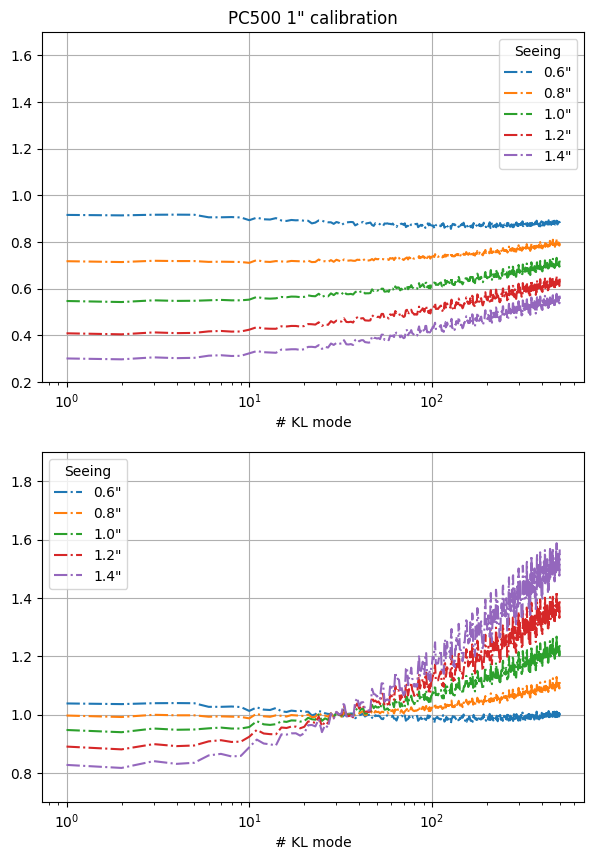

In [24]:
plt.figure(figsize=(7,10))
plt.subplot(2,1,1)
plt.semilogx(x,og_p1_pc500_s06,'-.',label='0.6"')
plt.semilogx(x,og_p1_pc500_s08,'-.',label='0.8"')
plt.semilogx(x,og_p1_pc500_s10,'-.',label='1.0"')
plt.semilogx(x,og_p1_pc500_s12,'-.',label='1.2"')
plt.semilogx(x,og_p1_pc500_s14,'-.',label='1.4"')
plt.ylim([0.2,1.7])
plt.title('PC500 1" calibration')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()
plt.subplot(2,1,2)
plt.semilogx(x,og_p1_pc500_s06/og_p1_pc500_s06[ogc_idx],'-.',label='0.6"')
plt.semilogx(x,og_p1_pc500_s08/og_p1_pc500_s08[ogc_idx],'-.',label='0.8"')
plt.semilogx(x,og_p1_pc500_s10/og_p1_pc500_s10[ogc_idx],'-.',label='1.0"')
plt.semilogx(x,og_p1_pc500_s12/og_p1_pc500_s12[ogc_idx],'-.',label='1.2"')
plt.semilogx(x,og_p1_pc500_s14/og_p1_pc500_s14[ogc_idx],'-.',label='1.4"')
plt.ylim([0.7,1.9])
# plt.title('Optical gain after OGC\nPC648 calibration 1"')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()

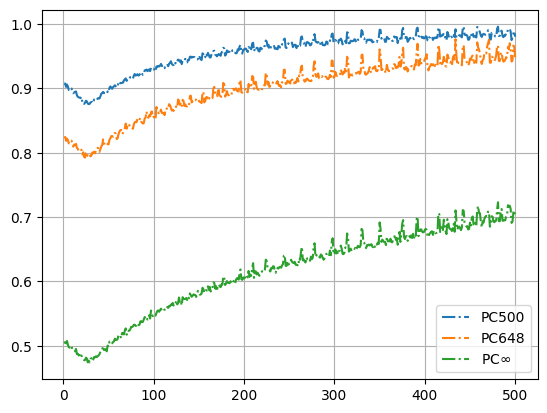

In [41]:
og_pc500 = np.diag(rec @ im_pyr3_pc500)
og_pc648 = np.diag(rec @ im_pyr3_pc648)
og_pcinf = np.diag(rec @ im_pyr3_pcinf)

plt.figure()
plt.plot(x,og_pc500,'-.',label='PC500')
plt.plot(x,og_pc648,'-.',label='PC648')
plt.plot(x,og_pcinf,'-.',label=r'PC$\infty$')
plt.legend()
plt.grid()

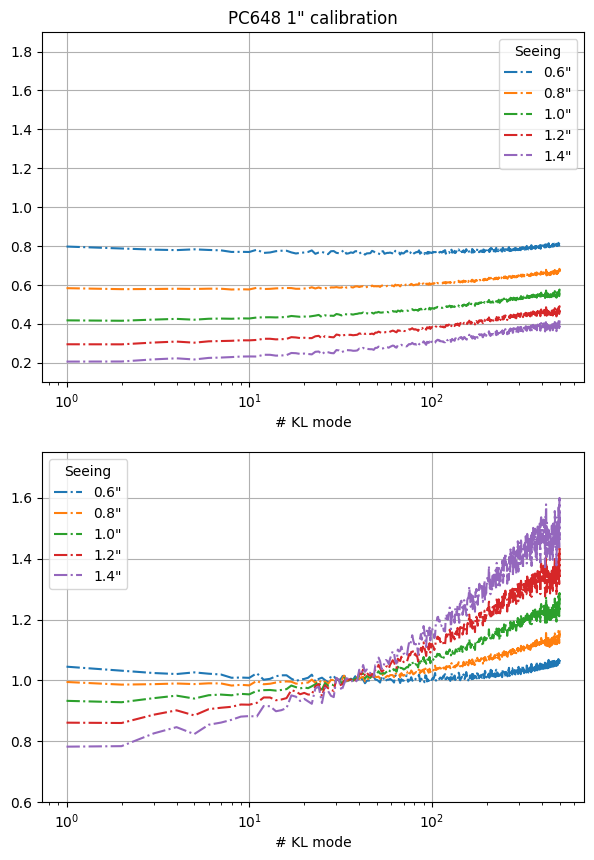

In [25]:
plt.figure(figsize=(7,10))
plt.subplot(2,1,1)
plt.semilogx(x,og_p0_pc648_s06,'-.',label='0.6"')
plt.semilogx(x,og_p0_pc648_s08,'-.',label='0.8"')
plt.semilogx(x,og_p0_pc648_s10,'-.',label='1.0"')
plt.semilogx(x,og_p0_pc648_s12,'-.',label='1.2"')
plt.semilogx(x,og_p0_pc648_s14,'-.',label='1.4"')
plt.ylim([0.1,1.9])
plt.title('PC648 1" calibration')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()
plt.subplot(2,1,2)
plt.semilogx(x,og_p0_pc648_s06/og_p0_pc648_s06[ogc_idx],'-.',label='0.6"')
plt.semilogx(x,og_p0_pc648_s08/og_p0_pc648_s08[ogc_idx],'-.',label='0.8"')
plt.semilogx(x,og_p0_pc648_s10/og_p0_pc648_s10[ogc_idx],'-.',label='1.0"')
plt.semilogx(x,og_p0_pc648_s12/og_p0_pc648_s12[ogc_idx],'-.',label='1.2"')
plt.semilogx(x,og_p0_pc648_s14/og_p0_pc648_s14[ogc_idx],'-.',label='1.4"')
plt.ylim([0.6,1.75])
# plt.title('Optical gain after OGC\nPC648 calibration 1"')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()

In [26]:
mat3 = rec @ im3_pc08
mat3_pc500 = rec3_pc500 @ im3_pc08
mat3_pc648 = rec3_pc648 @ im3_pc08
mat3_inf = rec3_pcinf @ im3_pc08


# plt.figure(figsize=(18,4))
# plt.subplot(1,3,1)
# plt.imshow(abs(mat3[:500,:]),vmin=0,vmax=0.06,cmap='turbo')
# plt.colorbar()
# plt.title(r'DL')
# plt.subplot(1,3,2)
# plt.imshow(abs(mat3_pc648[:500,:]),vmin=0,vmax=0.06,cmap='turbo')
# plt.colorbar()
# plt.title(r'PC648')
# plt.subplot(1,3,3)
# plt.imshow(abs(mat3_inf[:500,:]),vmin=0,vmax=0.06,cmap='turbo')
# plt.colorbar()
# plt.title(r'PC$\infty$')

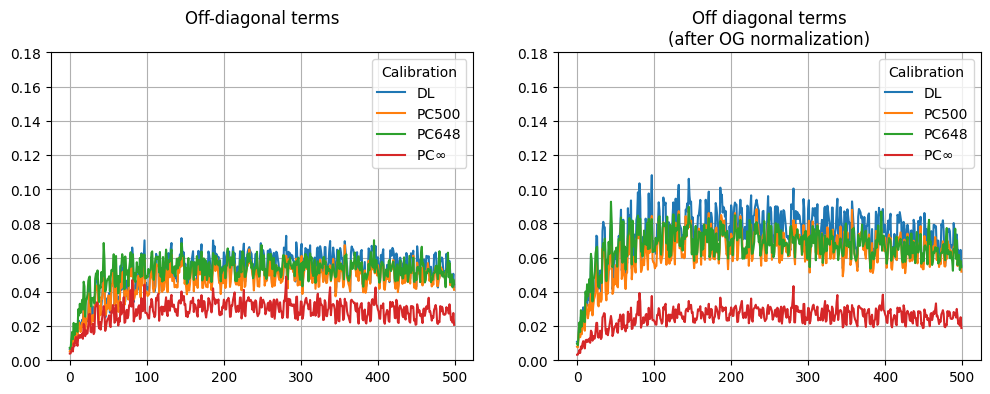

In [27]:
# ssq1 = np.sqrt(np.sum(mat3**2,axis=0)-np.diag(mat3)**2)
ssq = np.sqrt(np.sum(mat3**2,axis=0)-np.diag(mat3)**2)
ssq_pc5 = np.sqrt(np.sum(mat3_pc500**2,axis=0)-np.diag(mat3_pc500)**2)
ssq_pc = np.sqrt(np.sum(mat3_pc648**2,axis=0)-np.diag(mat3_pc648)**2)
ssq_inf = np.sqrt(np.sum(mat3_inf**2,axis=0)-np.diag(mat3_inf)**2)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(ssq,label='DL')
plt.plot(ssq_pc5,label='PC500')
plt.plot(ssq_pc,label='PC648')
plt.plot(ssq_inf,label=r'PC$\infty$')
plt.ylim([0,0.18])
plt.title('Off-diagonal terms\n')
plt.legend(title='Calibration')
plt.grid()
plt.subplot(1,2,2)
plt.plot(ssq/np.diag(mat3),label='DL')
plt.plot(ssq_pc5/np.diag(mat3_pc500),label='PC500')
plt.plot(ssq_pc/np.diag(mat3_pc648),label='PC648')
plt.plot(ssq_inf/np.diag(mat3_inf),label=r'PC$\infty$')
plt.ylim([0,0.18])
plt.legend(title='Calibration')
plt.title('Off diagonal terms\n(after OG normalization)')
plt.grid()

In [28]:
mat = rec0 @ im0_pc12
mat_pc500 = rec0_pc500 @ im0_pc12
mat_pc648 = rec0_pc648 @ im0_pc12
mat_inf = rec0_pcinf @ im0_pc12

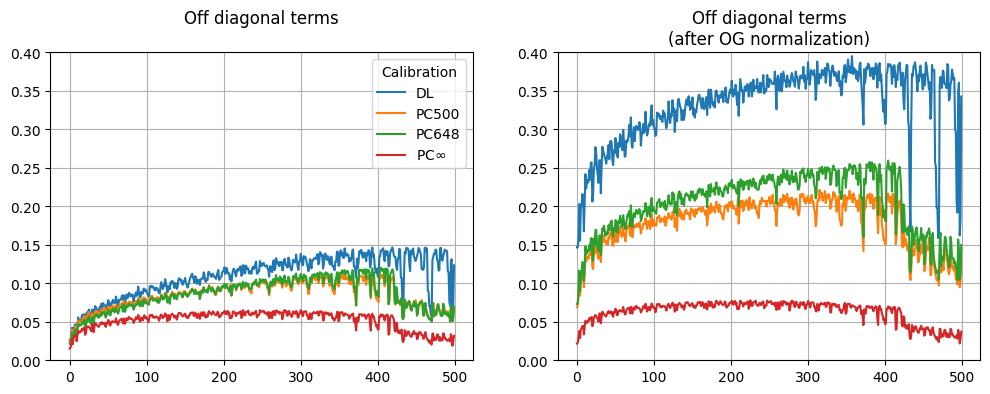

In [29]:
ssq = np.sqrt(np.sum(mat**2,axis=0)-np.diag(mat)**2)
ssq_pc5 = np.sqrt(np.sum(mat_pc500**2,axis=0)-np.diag(mat_pc500)**2)
ssq_pc = np.sqrt(np.sum(mat_pc648**2,axis=0)-np.diag(mat_pc648)**2)
ssq_inf = np.sqrt(np.sum(mat_inf**2,axis=0)-np.diag(mat_inf)**2)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(ssq,label='DL')
plt.plot(ssq_pc5,label='PC500')
plt.plot(ssq_pc,label='PC648')
plt.plot(ssq_inf,label=r'PC$\infty$')
plt.ylim([0,0.4])
plt.title('Off diagonal terms\n')
plt.legend(title='Calibration')
plt.grid()
plt.subplot(1,2,2)
plt.plot(ssq/np.diag(mat),label='DL')
plt.plot(ssq_pc5/np.diag(mat_pc500),label='PC500')
plt.plot(ssq_pc/np.diag(mat_pc648),label='PC648')
plt.plot(ssq_inf/np.diag(mat_inf),label=r'PC$\infty$')
plt.ylim([0,0.4])
plt.title('Off diagonal terms\n(after OG normalization)')
plt.grid()

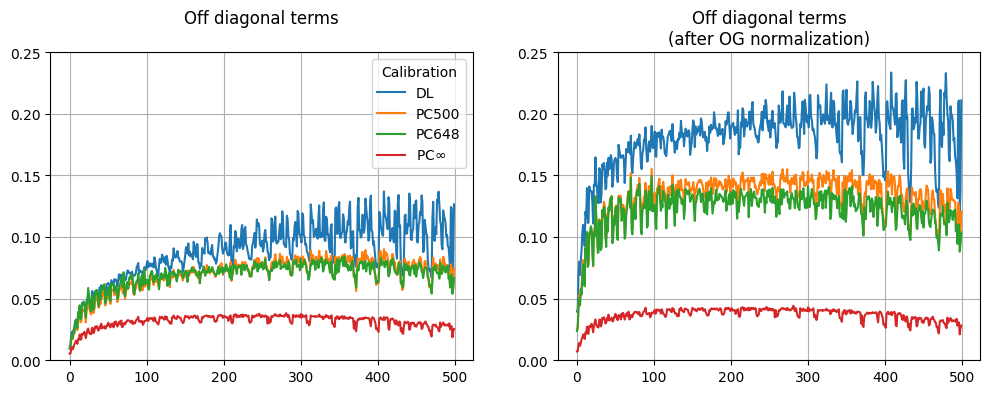

In [30]:
mat = rec1 @ im1_pc12
mat_pc500 = rec1_pc500 @ im1_pc12
mat_pc648 = rec1_pc648 @ im1_pc12
mat_inf = rec1_pcinf @ im1_pc12

ssq = np.sqrt(np.sum(mat**2,axis=0)-np.diag(mat)**2)
ssq_pc5 = np.sqrt(np.sum(mat_pc500**2,axis=0)-np.diag(mat_pc500)**2)
ssq_pc = np.sqrt(np.sum(mat_pc648**2,axis=0)-np.diag(mat_pc648)**2)
ssq_inf = np.sqrt(np.sum(mat_inf**2,axis=0)-np.diag(mat_inf)**2)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(ssq,label='DL')
plt.plot(ssq_pc,label='PC500')
plt.plot(ssq_pc5,label='PC648')
plt.plot(ssq_inf,label=r'PC$\infty$')
plt.ylim([0,0.25])
plt.title('Off diagonal terms\n')
plt.legend(title='Calibration')
plt.grid()
plt.subplot(1,2,2)
plt.plot(ssq/np.diag(mat),label='DL')
plt.plot(ssq_pc/np.diag(mat_pc648),label='PC500')
plt.plot(ssq_pc5/np.diag(mat_pc500),label='PC648')
plt.plot(ssq_inf/np.diag(mat_inf),label=r'PC$\infty$')
plt.ylim([0,0.25])
plt.title('Off diagonal terms\n(after OG normalization)')
plt.grid()

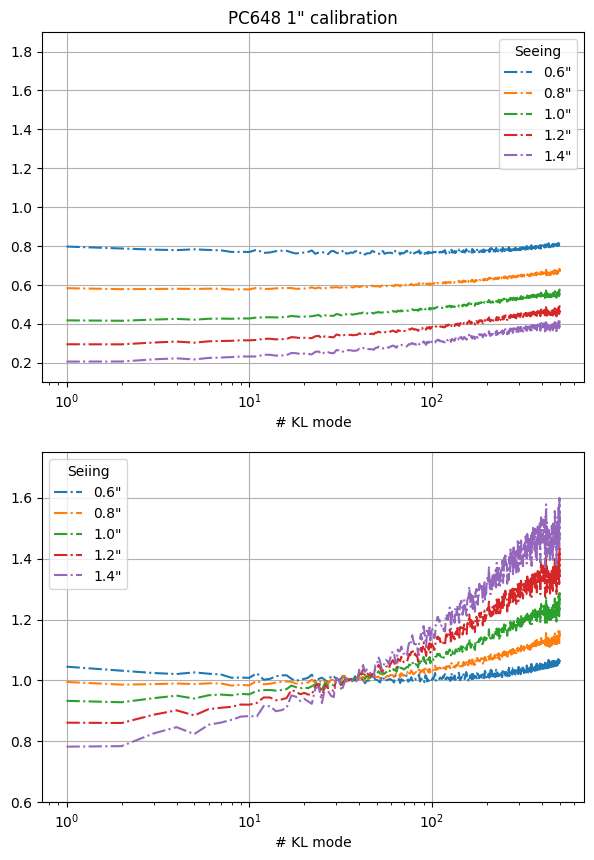

In [31]:
plt.figure(figsize=(7,10))
plt.subplot(2,1,1)
plt.semilogx(x,og_p0_pc648_s06,'-.',label='0.6"')
plt.semilogx(x,og_p0_pc648_s08,'-.',label='0.8"')
plt.semilogx(x,og_p0_pc648_s10,'-.',label='1.0"')
plt.semilogx(x,og_p0_pc648_s12,'-.',label='1.2"')
plt.semilogx(x,og_p0_pc648_s14,'-.',label='1.4"')
plt.ylim([0.1,1.9])
plt.title(r'PC648 1" calibration')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()
plt.subplot(2,1,2)
plt.semilogx(x,og_p0_pc648_s06/og_p0_pc648_s06[ogc_idx],'-.',label='0.6"')
plt.semilogx(x,og_p0_pc648_s08/og_p0_pc648_s08[ogc_idx],'-.',label='0.8"')
plt.semilogx(x,og_p0_pc648_s10/og_p0_pc648_s10[ogc_idx],'-.',label='1.0"')
plt.semilogx(x,og_p0_pc648_s12/og_p0_pc648_s12[ogc_idx],'-.',label='1.2"')
plt.semilogx(x,og_p0_pc648_s14/og_p0_pc648_s14[ogc_idx],'-.',label='1.4"')
plt.ylim([0.6,1.75])
# plt.title('Optical gain after OGC\nPCinf calibration 1"')
plt.xlabel('# KL mode')
plt.legend(title='Seiing')
plt.grid()

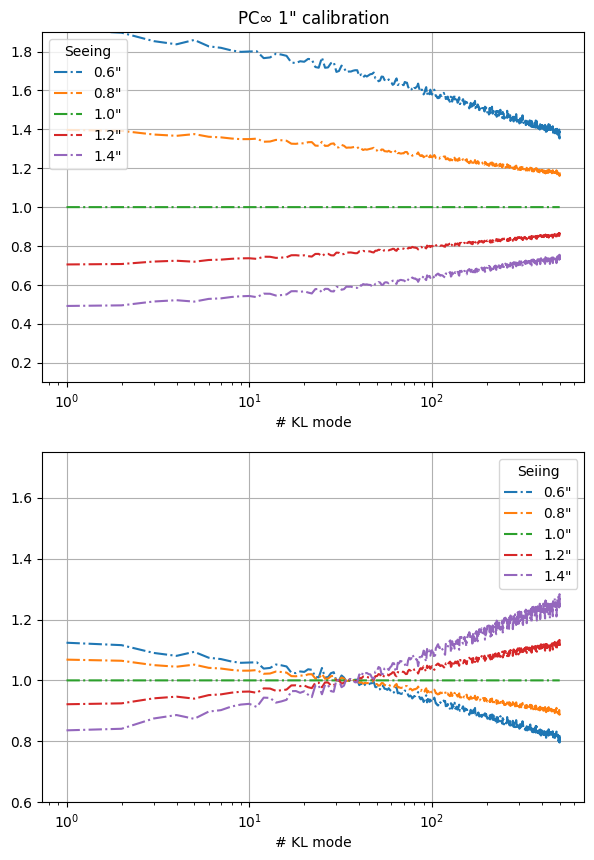

In [32]:
plt.figure(figsize=(7,10))
plt.subplot(2,1,1)
plt.semilogx(x,og_p0_pcinf_s06,'-.',label='0.6"')
plt.semilogx(x,og_p0_pcinf_s08,'-.',label='0.8"')
plt.semilogx(x,og_p0_pcinf_s10,'-.',label='1.0"')
plt.semilogx(x,og_p0_pcinf_s12,'-.',label='1.2"')
plt.semilogx(x,og_p0_pcinf_s14,'-.',label='1.4"')
plt.ylim([0.1,1.9])
plt.title(r'PC$\infty$ 1" calibration')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()
plt.subplot(2,1,2)
plt.semilogx(x,og_p0_pcinf_s06/og_p0_pcinf_s06[ogc_idx],'-.',label='0.6"')
plt.semilogx(x,og_p0_pcinf_s08/og_p0_pcinf_s08[ogc_idx],'-.',label='0.8"')
plt.semilogx(x,og_p0_pcinf_s10/og_p0_pcinf_s10[ogc_idx],'-.',label='1.0"')
plt.semilogx(x,og_p0_pcinf_s12/og_p0_pcinf_s12[ogc_idx],'-.',label='1.2"')
plt.semilogx(x,og_p0_pcinf_s14/og_p0_pcinf_s14[ogc_idx],'-.',label='1.4"')
plt.ylim([0.6,1.75])
# plt.title('Optical gain after OGC\nPCinf calibration 1"')
plt.xlabel('# KL mode')
plt.legend(title='Seiing')
plt.grid()

In [33]:
og_p1_dl_s10 = np.diag(rec1 @ im1_pc10) #np.diag(im.T @ im_pc10)/norm10
og_p1_pc648_s10 = np.diag(rec1_pc648 @ im1_pc10) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p1_pcinf_s10 = np.diag(rec1_pcinf @ im1_pc10) # np.diag(im_pyr3_pcinf.T @ im_pc10)/norm10

og_p1_dl_s06 = np.diag(rec1 @ im1_pc06) #np.diag(im.T @ im_pc10)/norm10
og_p1_pc648_s06 = np.diag(rec1_pc648 @ im1_pc06) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p1_pcinf_s06 = np.diag(rec1_pcinf @ im1_pc06) # np.diag(im_pyr3_pcinf.T @ im_pc10)/norm10

og_p1_dl_s08 = np.diag(rec1 @ im1_pc08) #np.diag(im.T @ im_pc10)/norm10
og_p1_pc648_s08 = np.diag(rec1_pc648 @ im1_pc08) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p1_pcinf_s08 = np.diag(rec1_pcinf @ im1_pc08) # np.diag(im_pyr3_pcinf.T @ im_pc10)/norm10

og_p1_dl_s12 = np.diag(rec1 @ im1_pc12) #np.diag(im.T @ im_pc10)/norm10
og_p1_pc648_s12 = np.diag(rec1_pc648 @ im1_pc12) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p1_pcinf_s12 = np.diag(rec1_pcinf @ im1_pc12) # np.diag(im_pyr3_pcinf.T @ im_pc10)/norm10

og_p1_dl_s14 = np.diag(rec1 @ im1_pc14) #np.diag(im.T @ im_pc10)/norm10
og_p1_pc648_s14 = np.diag(rec1_pc648 @ im1_pc14) #np.diag(im_pyr3_pc648.T @ im_pc10)/norm10
og_p1_pcinf_s14 = np.diag(rec1_pcinf @ im1_pc14) # np.diag(im_pyr3_pcinf.T @ im_pc10)/norm10

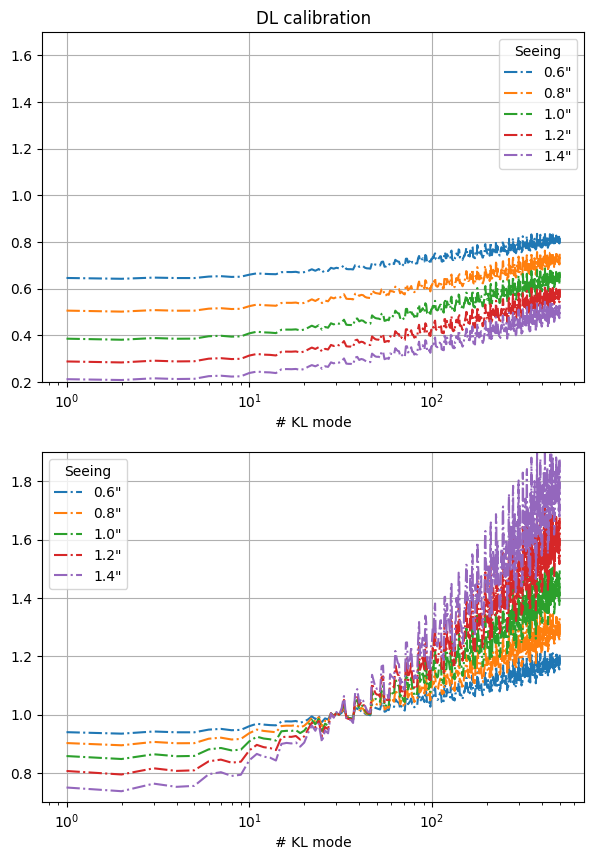

In [34]:
plt.figure(figsize=(7,10))
plt.subplot(2,1,1)
plt.semilogx(x,og_p1_dl_s06,'-.',label='0.6"')
plt.semilogx(x,og_p1_dl_s08,'-.',label='0.8"')
plt.semilogx(x,og_p1_dl_s10,'-.',label='1.0"')
plt.semilogx(x,og_p1_dl_s12,'-.',label='1.2"')
plt.semilogx(x,og_p1_dl_s14,'-.',label='1.4"')
plt.ylim([0.2,1.7])
plt.title(r'DL calibration')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()
plt.subplot(2,1,2)
plt.semilogx(x,og_p1_dl_s06/og_p1_dl_s06[ogc_idx],'-.',label='0.6"')
plt.semilogx(x,og_p1_dl_s08/og_p1_dl_s08[ogc_idx],'-.',label='0.8"')
plt.semilogx(x,og_p1_dl_s10/og_p1_dl_s10[ogc_idx],'-.',label='1.0"')
plt.semilogx(x,og_p1_dl_s12/og_p1_dl_s12[ogc_idx],'-.',label='1.2"')
plt.semilogx(x,og_p1_dl_s14/og_p1_dl_s14[ogc_idx],'-.',label='1.4"')
plt.ylim([0.7,1.9])
# plt.title('Optical gain after OGC\nDL calibration')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()

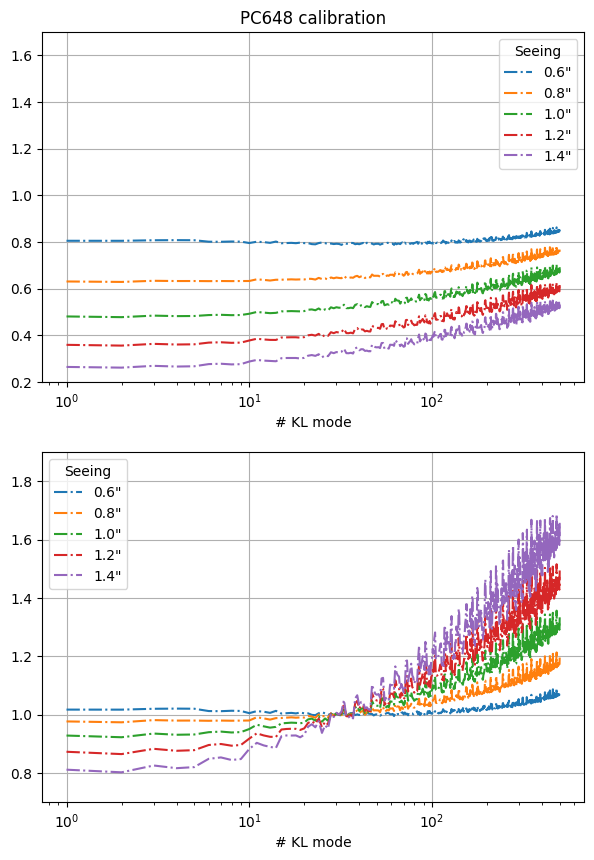

In [35]:
plt.figure(figsize=(7,10))
plt.subplot(2,1,1)
plt.semilogx(x,og_p1_pc648_s06,'-.',label='0.6"')
plt.semilogx(x,og_p1_pc648_s08,'-.',label='0.8"')
plt.semilogx(x,og_p1_pc648_s10,'-.',label='1.0"')
plt.semilogx(x,og_p1_pc648_s12,'-.',label='1.2"')
plt.semilogx(x,og_p1_pc648_s14,'-.',label='1.4"')
plt.ylim([0.2,1.7])
plt.title(r'PC648 calibration')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()
plt.subplot(2,1,2)
plt.semilogx(x,og_p1_pc648_s06/og_p1_pc648_s06[ogc_idx],'-.',label='0.6"')
plt.semilogx(x,og_p1_pc648_s08/og_p1_pc648_s08[ogc_idx],'-.',label='0.8"')
plt.semilogx(x,og_p1_pc648_s10/og_p1_pc648_s10[ogc_idx],'-.',label='1.0"')
plt.semilogx(x,og_p1_pc648_s12/og_p1_pc648_s12[ogc_idx],'-.',label='1.2"')
plt.semilogx(x,og_p1_pc648_s14/og_p1_pc648_s14[ogc_idx],'-.',label='1.4"')
plt.ylim([0.7,1.9])
# plt.title('Optical gain after OGC\nDL calibration')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()

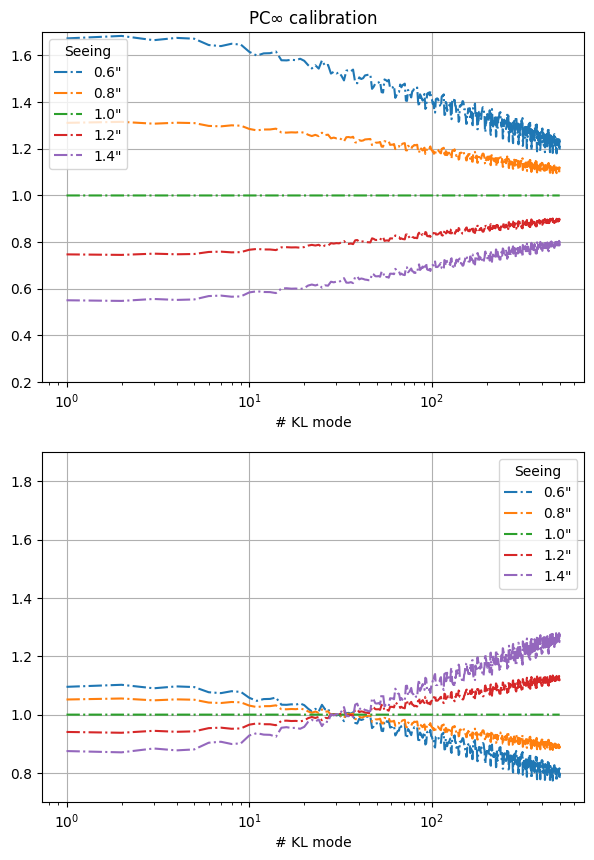

In [36]:
plt.figure(figsize=(7,10))
plt.subplot(2,1,1)
plt.semilogx(x,og_p1_pcinf_s06,'-.',label='0.6"')
plt.semilogx(x,og_p1_pcinf_s08,'-.',label='0.8"')
plt.semilogx(x,og_p1_pcinf_s10,'-.',label='1.0"')
plt.semilogx(x,og_p1_pcinf_s12,'-.',label='1.2"')
plt.semilogx(x,og_p1_pcinf_s14,'-.',label='1.4"')
plt.ylim([0.2,1.7])
plt.title(r'PC$\infty$ calibration')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()
plt.subplot(2,1,2)
plt.semilogx(x,og_p1_pcinf_s06/og_p1_pcinf_s06[ogc_idx],'-.',label='0.6"')
plt.semilogx(x,og_p1_pcinf_s08/og_p1_pcinf_s08[ogc_idx],'-.',label='0.8"')
plt.semilogx(x,og_p1_pcinf_s10/og_p1_pcinf_s10[ogc_idx],'-.',label='1.0"')
plt.semilogx(x,og_p1_pcinf_s12/og_p1_pcinf_s12[ogc_idx],'-.',label='1.2"')
plt.semilogx(x,og_p1_pcinf_s14/og_p1_pcinf_s14[ogc_idx],'-.',label='1.4"')
plt.ylim([0.7,1.9])
# plt.title('Optical gain after OGC\nDL calibration')
plt.xlabel('# KL mode')
plt.legend(title='Seeing')
plt.grid()

In [76]:
kl_inv = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/ifunc/asm_v30dx_kl_inv.fits')
idx = 100

kl = cpuArray(specula.xp.linalg.pinv(specula.xp.array(kl_inv)))

In [77]:
m2c = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/m2c/asm_v30dx_m2c_full.fits')
mode_ids = (np.sum(abs(m2c),axis=0)>0).astype(bool)

In [78]:
# pushpull = fits.getdata('/raid1/mmenessini/LBTData/CmdDisturb_20260518_134432.fits')
pushpull_ref = fits.getdata('/raid1/mmenessini/LBTData/CmdDisturb_20260522_121154.fits')
pushpull = fits.getdata('/raid1/mmenessini/LBTData/CmdDisturb_20260522_140501.fits')
print(pushpull.shape,m2c.shape)

(672, 4000) (672, 672)


In [79]:
delta = pushpull-pushpull_ref
pushpull = pushpull_ref+delta*1e-9

In [80]:
modal_pp = cpuArray(specula.xp.linalg.pinv(specula.xp.array(m2c))) @ pushpull

In [124]:
modal_pp_ref = cpuArray(specula.xp.linalg.pinv(specula.xp.array(m2c))) @ pushpull_ref

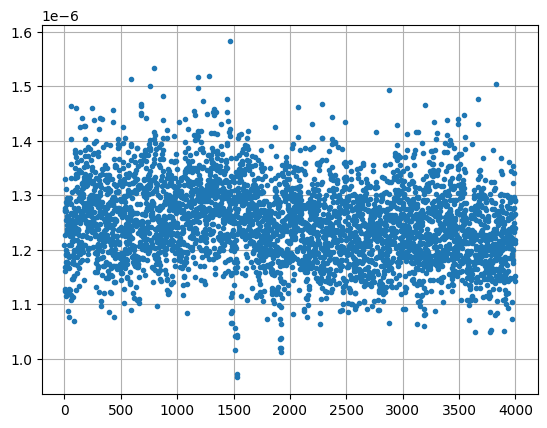

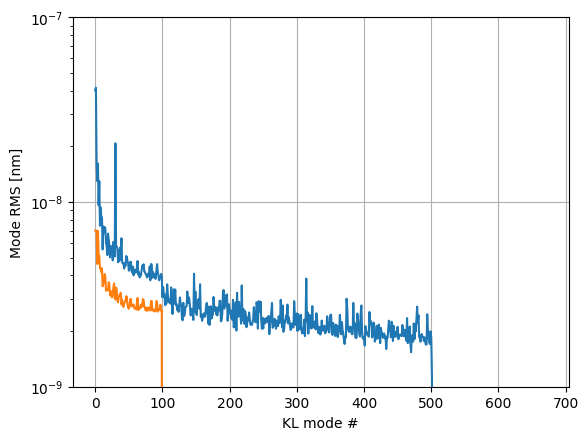

In [130]:
plt.figure()
plt.plot(np.sum(np.abs(modal_pp),axis=0),'.')
# plt.xlim([0,200])
plt.grid()

plt.figure()
plt.semilogy(np.sqrt(np.mean(modal_pp**2,axis=1)),label='PC calib')
plt.semilogy(np.sqrt(np.mean(modal_pp_ref**2,axis=1)),label='DL calib')
plt.xlabel('KL mode #')
plt.ylabel('Mode RMS [nm]')
plt.ylim([1e-9,1e-7])
plt.grid()

In [88]:
print(kl.shape)

(29901, 649)


In [89]:
# Zero padding for KL
kl_full = np.pad(kl,pad_width=(0,672-kl.shape[1]),mode='constant',constant_values=0.0)

In [90]:
phases = kl_full @ modal_pp

In [48]:
phs = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/20260508_150538/atmo_pc_phs.fits')
mask = np.sum(abs(phs[:,0,:,:])>0,axis=0).astype(bool)

In [142]:
def show2d(phase,mask,offset=None):
    img = np.zeros(mask.shape)
    img[mask] = phase[:np.sum(mask)]
    img = img.reshape(mask.shape)
    if offset is not None:
        img -= offset
    plt.imshow(np.ma.masked_array(img,mask=~mask),origin='lower',cmap='turbo')
    plt.colorbar()

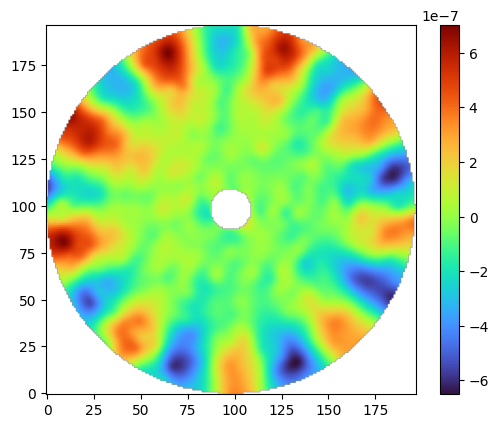

In [ ]:
idx = 99
show2d(phases[:,idx+1]+phases[:,idx+2]+phases[:,idx+3]-(phases[:,idx+4]+phases[:,idx+5]+phases[:,idx+6]),mask)

In [139]:
cube = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/data/20230507_030749_res_OPD_fit.fits')
cube.shape

(4000, 197, 197)

Text(0.5, 1.0, 'PC phase')

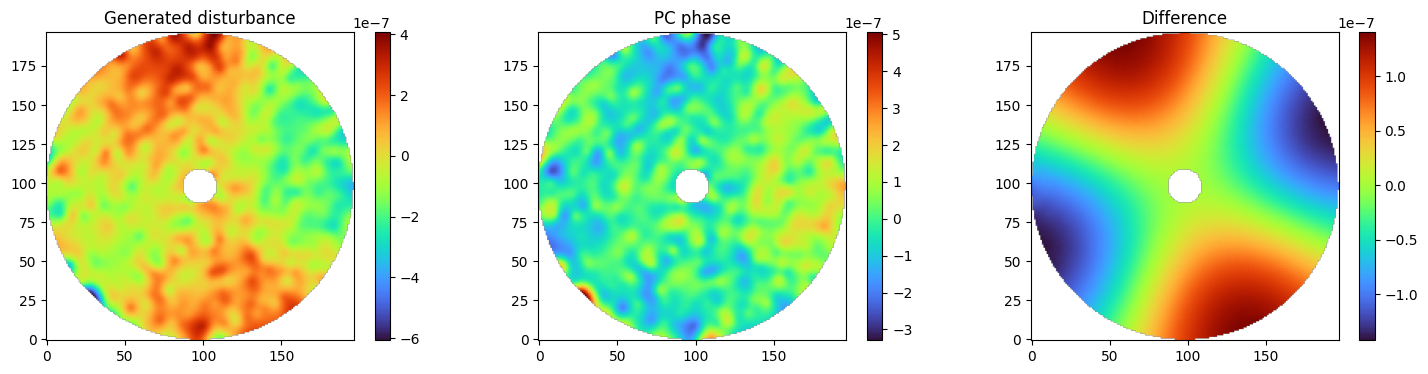

In [150]:
plt.figure(figsize=(18,4))
plt.subplot(1,3,1)
show2d(phases[:,200],mask=mask)
plt.title('Generated disturbance')
plt.subplot(1,3,3)
show2d(phases[:,200],offset=cube[200,:,:]*1e-9,mask=mask)
plt.title('Difference')
plt.subplot(1,3,2)
show2d(phases[:,200]*0,offset=cube[200,:,:]*1e-9,mask=mask)
plt.title('PC phase')

In [ ]:
idx = 100

Text(0.5, 1.0, 'Error after OGC\nRMS: 0.05 [rad]')

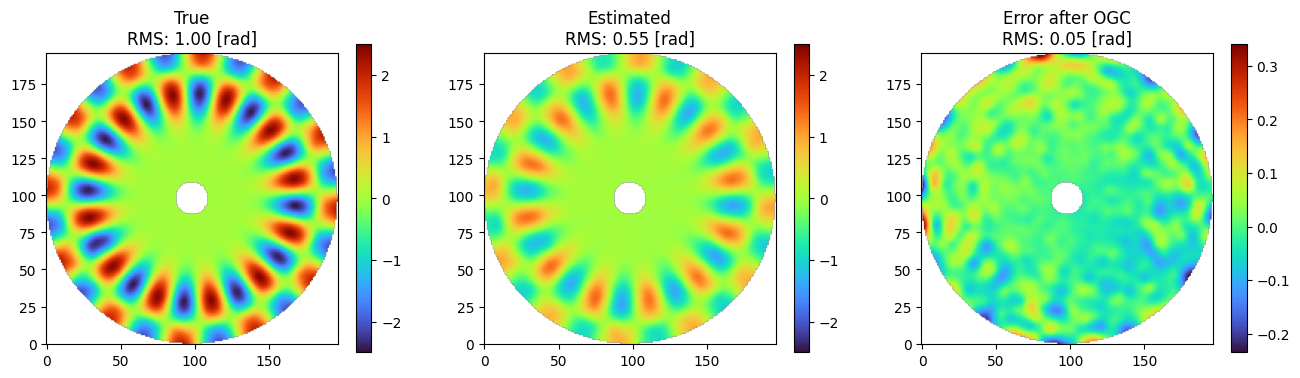

In [ ]:
coeffs = rec @ im3_pc10[:,idx]
coeffs = np.pad(coeffs,pad_width=(0,kl.shape[1]-len(coeffs)),mode='constant',constant_values=0.0)
shape = kl @ coeffs
true_shape = kl[:,idx]

img = np.zeros(mask.shape)
img_true = np.zeros(mask.shape)
img[mask] = shape
img_true[mask] = true_shape

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.imshow(np.ma.masked_array(img_true,mask=~mask),origin='lower',cmap='turbo',vmin=-2.5,vmax=2.5)
plt.colorbar()
plt.title(f'True\nRMS: {np.std(img_true[mask]):1.2f} [rad]')
plt.subplot(1,3,2)
plt.imshow(np.ma.masked_array(img,mask=~mask),origin='lower',cmap='turbo',vmin=-2.5,vmax=2.5)
plt.colorbar()
plt.title(f'Estimated\nRMS: {np.std(img[mask]):1.2f} [rad]')
plt.subplot(1,3,3)
plt.imshow(np.ma.masked_array(img-img_true*coeffs[idx],mask=~mask),origin='lower',cmap='turbo')
plt.colorbar()
plt.title(f'Error after OGC\nRMS: {np.std(img[mask]-img_true[mask]*coeffs[idx]):1.2f} [rad]')

In [ ]:
# print(modal_pp.shape,kl.shape)
# shape = kl @ modal_pp[:649,106]
# img = np.zeros(mask.shape)
# img[mask] = shape

# plt.figure()
# plt.imshow(np.ma.masked_array(img,mask=~mask),origin='lower',cmap='turbo')
# plt.colorbar()

In [ ]:
rec_pc_zerofit = cpuArray(specula.xp.linalg.pinv(specula.xp.array(im_pc_zerofit)))

Text(0.5, 1.0, 'Error after OGC\nRMS: 0.06 [rad]')

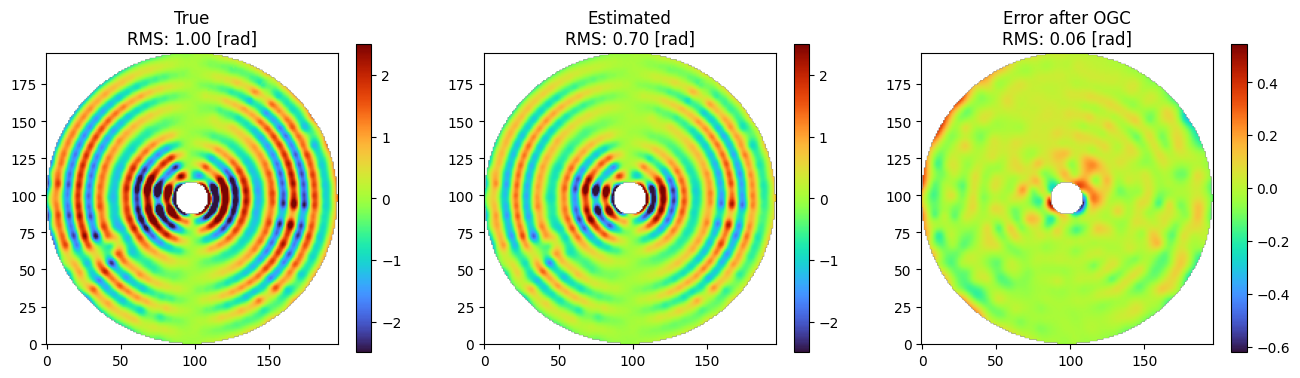

In [ ]:
coeffs = rec_pc_zerofit @ im_pc[:,idx]
coeffs = np.pad(coeffs,pad_width=(0,kl.shape[1]-len(coeffs)),mode='constant',constant_values=0.0)
shape = kl @ coeffs
true_shape = kl[:,idx]

img = np.zeros(mask.shape)
img_true = np.zeros(mask.shape)
img[mask] = shape
img_true[mask] = true_shape

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.imshow(np.ma.masked_array(img_true,mask=~mask),origin='lower',cmap='turbo',vmin=-2.5,vmax=2.5)
plt.colorbar()
plt.title(f'True\nRMS: {np.std(img_true[mask]):1.2f} [rad]')
plt.subplot(1,3,2)
plt.imshow(np.ma.masked_array(img,mask=~mask),origin='lower',cmap='turbo',vmin=-2.5,vmax=2.5)
plt.colorbar()
plt.title(f'Estimated\nRMS: {np.std(img[mask]):1.2f} [rad]')
plt.subplot(1,3,3)
plt.imshow(np.ma.masked_array(img-img_true*coeffs[idx],mask=~mask),origin='lower',cmap='turbo')
plt.colorbar()
plt.title(f'Error after OGC\nRMS: {np.std(img[mask]-img_true[mask]*coeffs[idx]):1.2f} [rad]')

Text(0.5, 1.0, 'Error after OGC\nRMS: 0.06 [rad]')

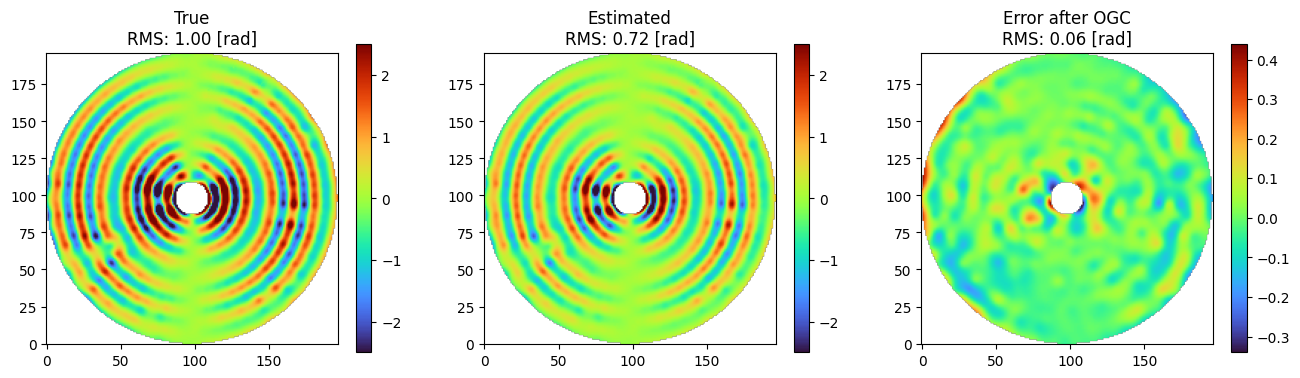

In [ ]:
coeffs = rec_pc_nofit @ im_pc[:,idx]
coeffs = np.pad(coeffs,pad_width=(0,kl.shape[1]-len(coeffs)),mode='constant',constant_values=0.0)
shape = kl @ coeffs
true_shape = kl[:,idx]

img = np.zeros(mask.shape)
img_true = np.zeros(mask.shape)
img[mask] = shape
img_true[mask] = true_shape

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.imshow(np.ma.masked_array(img_true,mask=~mask),origin='lower',cmap='turbo',vmin=-2.5,vmax=2.5)
plt.colorbar()
plt.title(f'True\nRMS: {np.std(img_true[mask]):1.2f} [rad]')
plt.subplot(1,3,2)
plt.imshow(np.ma.masked_array(img,mask=~mask),origin='lower',cmap='turbo',vmin=-2.5,vmax=2.5)
plt.colorbar()
plt.title(f'Estimated\nRMS: {np.std(img[mask]):1.2f} [rad]')
plt.subplot(1,3,3)
plt.imshow(np.ma.masked_array(img-img_true*coeffs[idx],mask=~mask),origin='lower',cmap='turbo')
plt.colorbar()
plt.title(f'Error after OGC\nRMS: {np.std(img[mask]-img_true[mask]*coeffs[idx]):1.2f} [rad]')

np.float32(0.052164745)

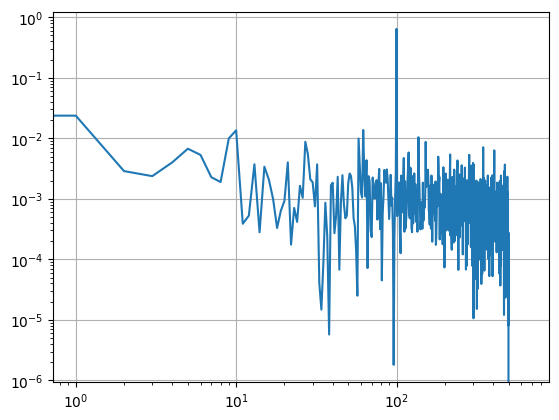

In [ ]:
plt.figure()
plt.loglog(np.abs(coeffs))
plt.grid()

np.sqrt(np.sum(coeffs**2)-coeffs[idx]**2)

In [ ]:
rec_pc = cpuArray(specula.xp.linalg.pinv(specula.xp.array(im_pc)))

Text(0.5, 1.0, 'Error after OGC\nRMS: 0.00 [rad]')

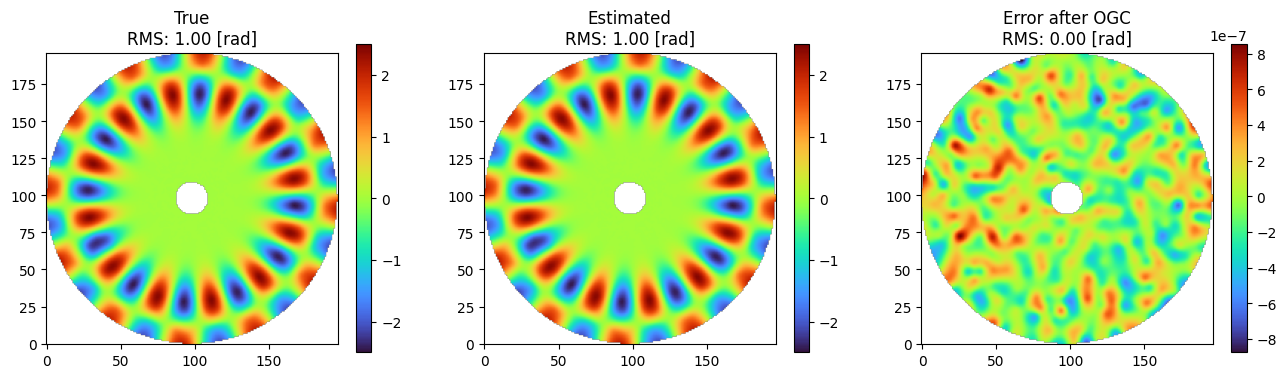

In [ ]:
coeffs = rec_pc @ im_pc[:,idx]
coeffs = np.pad(coeffs,pad_width=(0,kl.shape[1]-len(coeffs)),mode='constant',constant_values=0.0)
shape = kl @ coeffs
true_shape = kl[:,idx]

img = np.zeros(mask.shape)
img_true = np.zeros(mask.shape)
img[mask] = shape
img_true[mask] = true_shape

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.imshow(np.ma.masked_array(img_true,mask=~mask),origin='lower',cmap='turbo',vmin=-2.5,vmax=2.5)
plt.colorbar()
plt.title(f'True\nRMS: {np.std(img_true[mask]):1.2f} [rad]')
plt.subplot(1,3,2)
plt.imshow(np.ma.masked_array(img,mask=~mask),origin='lower',cmap='turbo',vmin=-2.5,vmax=2.5)
plt.colorbar()
plt.title(f'Estimated\nRMS: {np.std(img[mask]):1.2f} [rad]')
plt.subplot(1,3,3)
plt.imshow(np.ma.masked_array(img-img_true*coeffs[idx],mask=~mask),origin='lower',cmap='turbo')
plt.colorbar()
plt.title(f'Error after OGC\nRMS: {np.std(img[mask]-img_true[mask]*coeffs[idx]):1.2f} [rad]')

In [ ]:
raise ValueError()


ValueError: 

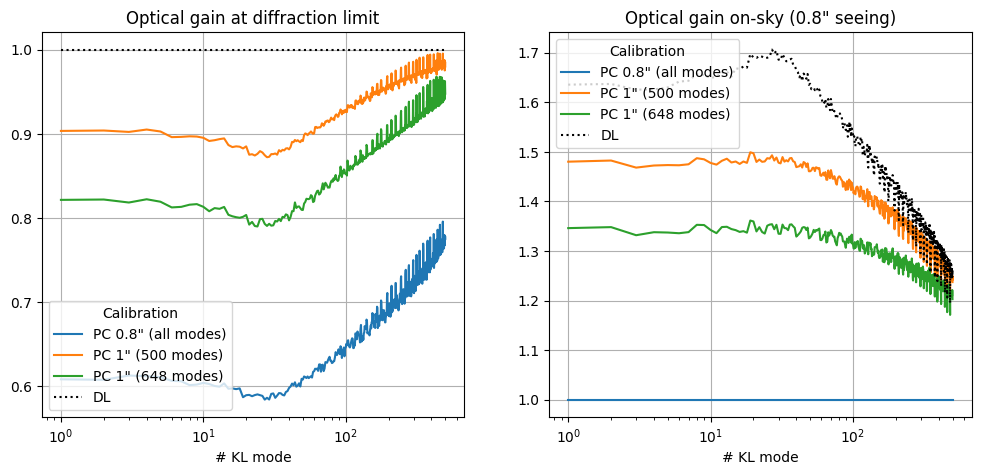

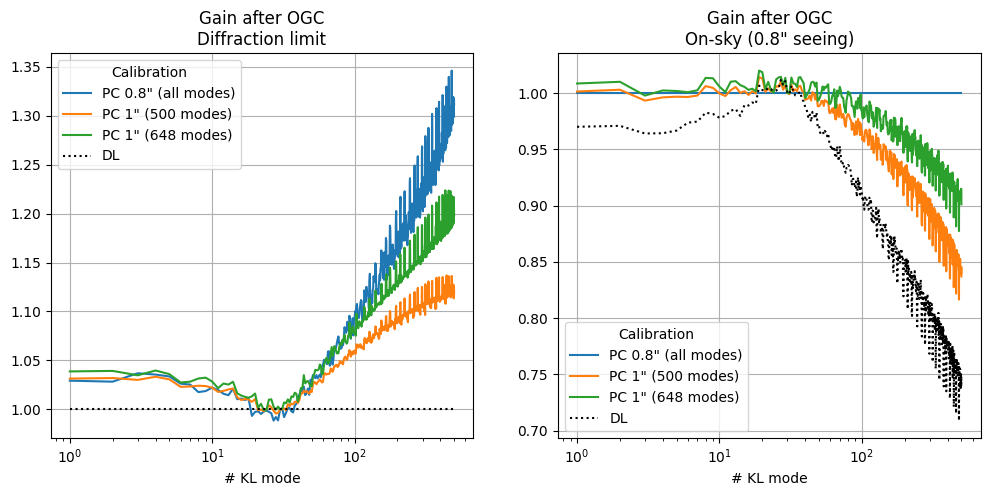

In [ ]:


norm_pc08 = np.diag(im_pc08.T @ im_pc08)

og = np.diag(im_pc08.T @ im)/norm
og_nofit = np.diag(im_pc_nofit.T @ im)/norm
og_zerofit = np.diag(im_pc_zerofit.T @ im)/norm

og_pc_dl = np.diag(im.T @ im_pc08)/norm_pc08
og_pc = np.diag(im_pc08.T @ im_pc08)/norm_pc08
og_pc_nofit = np.diag(im_pc_nofit.T @ im_pc08)/norm_pc08
og_pc_zerofit = np.diag(im_pc_zerofit.T @ im_pc08)/norm_pc08

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.semilogx(x,og,label='PC 0.8" (all modes)')
plt.semilogx(x,og_zerofit,label='PC 1" (500 modes)')
plt.semilogx(x,og_nofit,label='PC 1" (648 modes)')
plt.semilogx(x,og_dl,':',label='DL',c='k')
plt.title('Optical gain at diffraction limit')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()
plt.subplot(1,2,2)
plt.semilogx(x,og_pc,label='PC 0.8" (all modes)')
plt.semilogx(x,og_pc_zerofit,label='PC 1" (500 modes)')
plt.semilogx(x,og_pc_nofit,label='PC 1" (648 modes)')
plt.semilogx(x,og_pc_dl,':',label='DL',c='k')
plt.title('Optical gain on-sky (0.8" seeing)')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.semilogx(x,og/og[kl_ogc],label='PC 0.8" (all modes)')
plt.semilogx(x,og_zerofit/og_zerofit[kl_ogc],label='PC 1" (500 modes)')
plt.semilogx(x,og_nofit/og_nofit[kl_ogc],label='PC 1" (648 modes)')
plt.semilogx(x,og_dl/og_dl[kl_ogc],':',label='DL',c='k')
plt.title('Gain after OGC\nDiffraction limit')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()
plt.subplot(1,2,2)
plt.semilogx(x,og_pc/og_pc[kl_ogc],label='PC 0.8" (all modes)')
plt.semilogx(x,og_pc_zerofit/og_pc_zerofit[kl_ogc],label='PC 1" (500 modes)')
plt.semilogx(x,og_pc_nofit/og_pc_nofit[kl_ogc],label='PC 1" (648 modes)')
plt.semilogx(x,og_pc_dl/og_pc_dl[kl_ogc],':',label='DL',c='k')
plt.title('Gain after OGC\nOn-sky (0.8" seeing)')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()

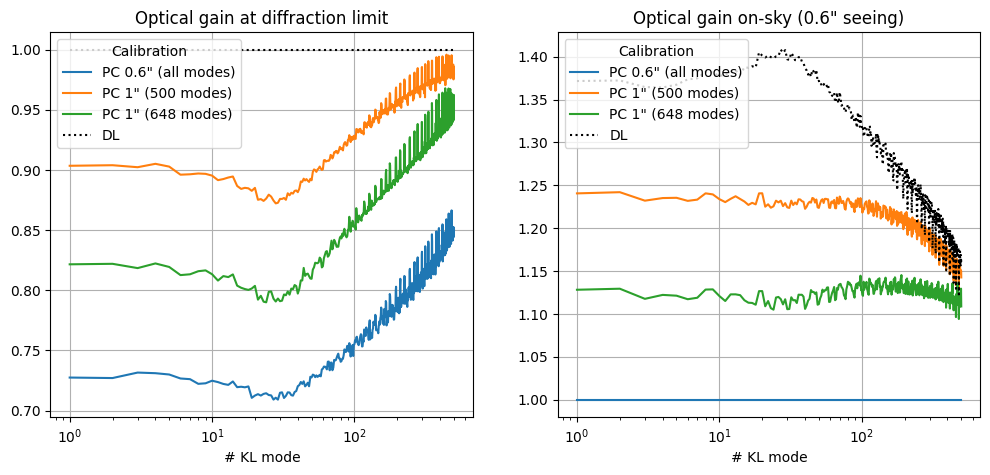

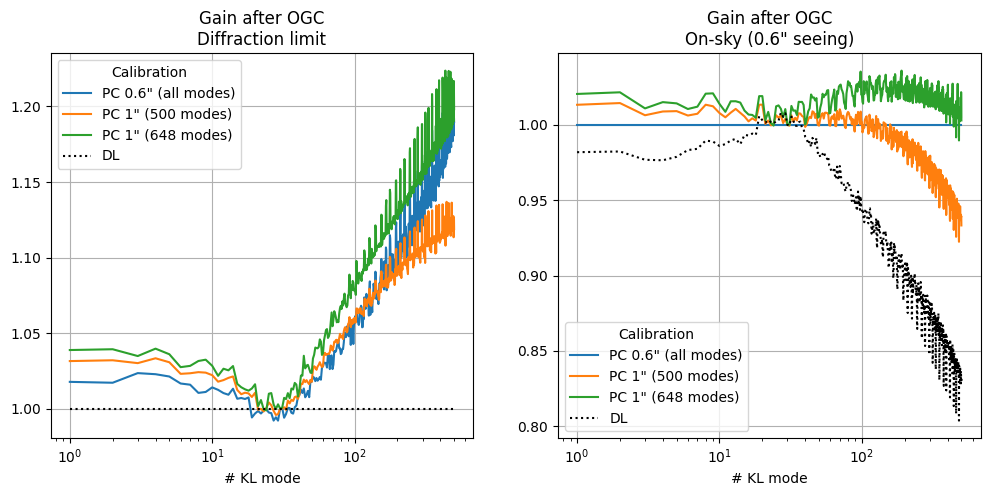

In [ ]:


norm_pc06 = np.diag(im_pc06.T @ im_pc06)

og = np.diag(im_pc06.T @ im)/norm
og_nofit = np.diag(im_pc_nofit.T @ im)/norm
og_zerofit = np.diag(im_pc_zerofit.T @ im)/norm

og_pc_dl = np.diag(im.T @ im_pc06)/norm_pc06
og_pc = np.diag(im_pc06.T @ im_pc06)/norm_pc06
og_pc_nofit = np.diag(im_pc_nofit.T @ im_pc06)/norm_pc06
og_pc_zerofit = np.diag(im_pc_zerofit.T @ im_pc06)/norm_pc06

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.semilogx(x,og,label='PC 0.6" (all modes)')
plt.semilogx(x,og_zerofit,label='PC 1" (500 modes)')
plt.semilogx(x,og_nofit,label='PC 1" (648 modes)')
plt.semilogx(x,og_dl,':',label='DL',c='k')
plt.title('Optical gain at diffraction limit')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()
plt.subplot(1,2,2)
plt.semilogx(x,og_pc,label='PC 0.6" (all modes)')
plt.semilogx(x,og_pc_zerofit,label='PC 1" (500 modes)')
plt.semilogx(x,og_pc_nofit,label='PC 1" (648 modes)')
plt.semilogx(x,og_pc_dl,':',label='DL',c='k')
plt.title('Optical gain on-sky (0.6" seeing)')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.semilogx(x,og/og[kl_ogc],label='PC 0.6" (all modes)')
plt.semilogx(x,og_zerofit/og_zerofit[kl_ogc],label='PC 1" (500 modes)')
plt.semilogx(x,og_nofit/og_nofit[kl_ogc],label='PC 1" (648 modes)')
plt.semilogx(x,og_dl/og_dl[kl_ogc],':',label='DL',c='k')
plt.title('Gain after OGC\nDiffraction limit')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()
plt.subplot(1,2,2)
plt.semilogx(x,og_pc/og_pc[kl_ogc],label='PC 0.6" (all modes)')
plt.semilogx(x,og_pc_zerofit/og_pc_zerofit[kl_ogc],label='PC 1" (500 modes)')
plt.semilogx(x,og_pc_nofit/og_pc_nofit[kl_ogc],label='PC 1" (648 modes)')
plt.semilogx(x,og_pc_dl/og_pc_dl[kl_ogc],':',label='DL',c='k')
plt.title('Gain after OGC\nOn-sky (0.6" seeing)')
plt.xlabel('# KL mode')
plt.legend(title='Calibration')
plt.grid()

Text(0.5, 1.0, 'Mode 4 slopes')

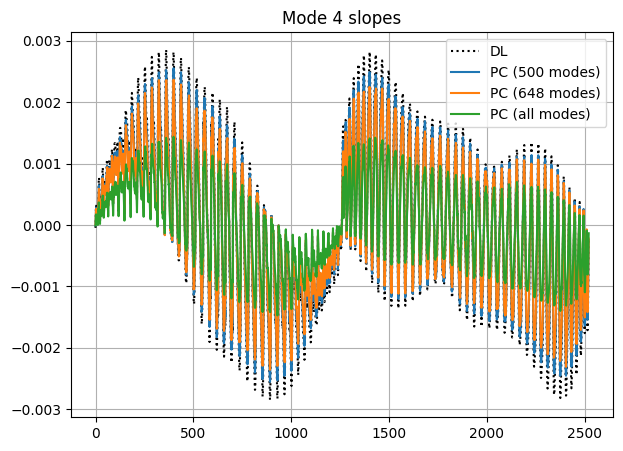

In [ ]:
idx = 4

slopes_dl = im[:,idx]
slopes_pc = im_pc[:,idx]
slopes_pc_zerofit = im_pc_zerofit[:,idx]
slopes_pc_nofit = im_pc_nofit[:,idx]

plt.figure(figsize=(7,5))
plt.plot(slopes_dl,':',label='DL',c='k')
plt.plot(slopes_pc_zerofit,label='PC (500 modes)')
plt.plot(slopes_pc_nofit,label='PC (648 modes)')
plt.plot(slopes_pc,label='PC (all modes)')
plt.grid()
plt.legend()
plt.title(f'Mode {idx} slopes')

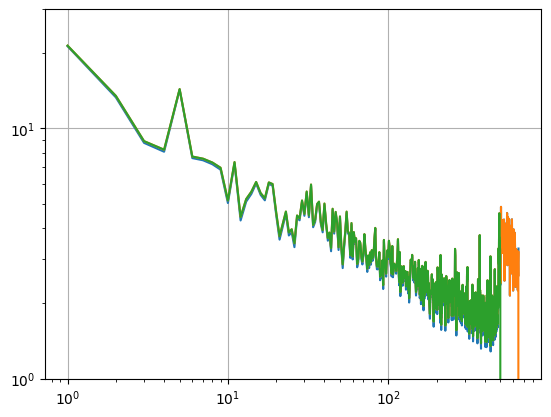

In [ ]:
atmo_modes_nofit = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/20260511_173304/atmo_res.fits')
atmo_modes_somefit = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/20260512_101506/atmo_res.fits')
atmo_modes = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/20260511_171947/atmo_res.fits') # 1.0" seeing
# atmo_modes = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/20260512_112945/atmo_res.fits') # 0.6" seeing


atmo_rms = np.sqrt(np.mean(atmo_modes**2,axis=0))#*(1/0.6)**(5/6)
atmo_rms_nofit = np.sqrt(np.mean(atmo_modes_nofit**2,axis=0))
atmo_rms_somefit = np.sqrt(np.mean(atmo_modes_somefit**2,axis=0))

plt.figure()
plt.loglog(np.arange(len(atmo_rms))+1,atmo_rms)
plt.loglog(np.arange(len(atmo_rms_nofit))+1,atmo_rms_somefit)
plt.loglog(np.arange(len(atmo_rms_nofit))+1,atmo_rms_nofit)
plt.ylim([1,30])
plt.grid()